# GTEx LV importance — tissue ORA (Cell Markers + KEGG)

1. Load the CLAMP Z matrix (genes × LVs) and pre-computed SHAP results
2. Select valid tissues based on k-means cluster purity and RF balanced accuracy
3. Identify top LVs per tissue covering 25% of cumulative SHAP importance
4. Extract top-loaded genes (top 1% by |Z|) per LV
5. Run ORA (hypergeometric + BH) against cell-type markers (MSigDB C8) and KEGG pathways
6. Visualise top enriched sets per tissue as bubble plots
7. Repeat ORA independently per LV (not pooled) and combine results per tissue

💡 **Environment:** `clamp-analyses`

# Libraries

In [1]:
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

readRDS = ro.r['readRDS']
from pyprojroot.here import here

np.random.seed(42)

# Settings

In [2]:
MIN_PURITY   = 0.80
MIN_RF_ACC   = 0.80
CUMUL_PCT    = 25      # top LVs covering this % cumulative SHAP
TOP_GENE_PCT = 0.01    # top 1% genes per LV by |Z| loading
FDR_THRESH   = 0.05

# Input

In [3]:
rds = readRDS(str(here('output/01_model_building/02_gtex/01_CLAMP/CLAMPfull.rds')))

def extract_Z_matrix(rds_obj):
    Z_mat = rds_obj.rx2('Z')
    with localconverter(ro.default_converter + pandas2ri.converter):
        Z_values = ro.conversion.rpy2py(Z_mat)
    return pd.DataFrame(
        Z_values,
        index=list(Z_mat.rownames) if Z_mat.rownames else None,
        columns=list(Z_mat.colnames) if Z_mat.colnames else None,
    )

Z_mat     = extract_Z_matrix(rds)
all_genes = Z_mat.index.tolist()

print(f'Z matrix: {Z_mat.shape[0]} genes × {Z_mat.shape[1]} LVs')
print(f'Example genes: {all_genes[:6]}')

Z matrix: 21613 genes × 578 LVs
Example genes: ['WASH7P', 'RP11-34P13.15', 'RP11-34P13.16', 'RP11-34P13.18', 'AP006222.2', 'MTND1P23']


In [4]:
shap_dir = here('output/03_model_biology/01_gtex/02_LV_importance_kmeans_biology')

accuracy = pd.read_csv(shap_dir / 'accuracy_summary.tsv',    sep='\t')
shap_all = pd.read_csv(shap_dir / 'all_shap_positive.tsv',   sep='\t')
cumul    = pd.read_csv(shap_dir / 'cumulative_importance.tsv', sep='\t')

print(f'Tissues in accuracy: {len(accuracy)}')
shap_all.head()

Tissues in accuracy: 23


,Feature,Mean_SHAP_Tissue,Cumulative_SHAP,Cumulative_Percent,Rank,Tissue
0,LV183,0.137534,0.137534,14.365823,1,Adrenal Gland
1,LV3,0.131097,0.268631,28.059334,2,Adrenal Gland
2,LV188,0.043266,0.311896,32.578564,3,Adrenal Gland
3,LV55,0.034924,0.346820,36.226448,4,Adrenal Gland
4,LV277,0.033655,0.380475,39.741865,5,Adrenal Gland


In [5]:
valid_tissues = sorted(
    accuracy[
        (accuracy['Mean_Purity']                  >= MIN_PURITY) &
        (accuracy['Best_Test_Balanced_Accuracy']  >= MIN_RF_ACC)
    ]['Tissue'].tolist()
)
print(f'Valid tissues ({len(valid_tissues)}):')
for t in valid_tissues:
    print(f'  - {t}')

Valid tissues (23):
  - Adrenal Gland
  - Artery - Tibial
  - Cells - Cultured fibroblasts
  - Cells - EBV-transformed lymphocytes
  - Colon - Transverse
  - Esophagus - Mucosa
  - Heart - Atrial Appendage
  - Heart - Left Ventricle
  - Kidney - Cortex
  - Liver
  - Lung
  - Muscle - Skeletal
  - Nerve - Tibial
  - Ovary
  - Pancreas
  - Pituitary
  - Prostate
  - Small Intestine - Terminal Ileum
  - Stomach
  - Testis
  - Thyroid
  - Vagina
  - Whole Blood


In [6]:
top_per_tissue = {}
for tissue in valid_tissues:
    df_t = cumul[cumul['Tissue'] == tissue].sort_values('Rank')
    hit  = df_t[df_t['Cumulative_Percent'] >= CUMUL_PCT]
    n    = int(hit['Rank'].iloc[0]) if len(hit) > 0 else len(df_t)
    top_per_tissue[tissue] = (
        shap_all[shap_all['Tissue'] == tissue]
        .sort_values('Rank')
        .head(n)['Feature']
        .tolist()
    )

pd.DataFrame({
    'Tissue': list(top_per_tissue),
    'N_LVs':  [len(v) for v in top_per_tissue.values()],
})

,Tissue,N_LVs
0,Adrenal Gland,2
1,Artery - Tibial,4
2,Cells - Cultured fibroblasts,4
3,Cells - EBV-transformed lymphocytes,6
4,Colon - Transverse,3
5,Esophagus - Mucosa,3
6,Heart - Atrial Appendage,2
7,Heart - Left Ventricle,6
8,Kidney - Cortex,2
9,Liver,3


## Build gene lists per tissue

In [7]:
n_top_genes = max(1, int(len(Z_mat) * TOP_GENE_PCT))
print(f'Top genes per LV: {n_top_genes}')

# Pre-compute top genes per LV (by |Z| loading)
lv_top_genes = {
    lv: Z_mat[lv].abs().nlargest(n_top_genes).index.tolist()
    for lv in Z_mat.columns
}

# Pool (deduplicated) across top LVs for each tissue
tissue_genes = {
    tissue: list(dict.fromkeys(
        gene
        for lv in top_per_tissue[tissue]
        for gene in lv_top_genes[lv]
    ))
    for tissue in valid_tissues
}

pd.DataFrame({
    'Tissue':  valid_tissues,
    'N_LVs':   [len(top_per_tissue[t]) for t in valid_tissues],
    'N_Genes': [len(tissue_genes[t])   for t in valid_tissues],
})

Top genes per LV: 216


,Tissue,N_LVs,N_Genes
0,Adrenal Gland,2,363
1,Artery - Tibial,4,784
2,Cells - Cultured fibroblasts,4,852
3,Cells - EBV-transformed lymphocytes,6,1220
4,Colon - Transverse,3,490
5,Esophagus - Mucosa,3,604
6,Heart - Atrial Appendage,2,371
7,Heart - Left Ventricle,6,1216
8,Kidney - Cortex,2,375
9,Liver,3,471


## MSigDB gene sets

In [8]:
ro.r('suppressPackageStartupMessages(library(msigdbr))')

ro.r('''
c8_df_r   <- as.data.frame(msigdbr(species="Homo sapiens", category="C8"))
kegg_df_r <- as.data.frame(msigdbr(species="Homo sapiens", category="C2",
                                    subcategory="CP:KEGG_LEGACY"))
''')

with localconverter(ro.default_converter + pandas2ri.converter):
    c8_df   = ro.conversion.rpy2py(ro.r['c8_df_r'])
    kegg_df = ro.conversion.rpy2py(ro.r['kegg_df_r'])

c8_t2g   = c8_df.groupby('gs_name')['gene_symbol'].apply(list).to_dict()
kegg_t2g = kegg_df.groupby('gs_name')['gene_symbol'].apply(list).to_dict()

print(f'C8 gene sets:   {len(c8_t2g)}'
      f'   unique genes: {len(set(g for gs in c8_t2g.values() for g in gs))}')
print(f'KEGG gene sets: {len(kegg_t2g)}'
      f'   unique genes: {len(set(g for gs in kegg_t2g.values() for g in gs))}')

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: The `category` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
ℹ Please use the `collection` argument instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
  
R callback write-console: 2: The `subcategory` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
ℹ Please use the `subcollection` argument instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
  


C8 gene sets:   866   unique genes: 20573
KEGG gene sets: 186   unique genes: 5246


## Run ORA

In [9]:
def run_ora(query_genes, term2gene, background, min_gs=10, max_gs=500):
    """Hypergeometric ORA with BH correction."""
    bg_set    = set(background)
    query_set = set(query_genes) & bg_set
    N = len(bg_set)
    K = len(query_set)
    if K == 0:
        return None

    results = []
    for gs_name, gs_genes in term2gene.items():
        gs_bg = set(gs_genes) & bg_set
        M     = len(gs_bg)
        if M < min_gs or M > max_gs:
            continue
        k = len(query_set & gs_bg)
        if k == 0:
            continue
        results.append({
            'ID':        gs_name,
            'GeneRatio': f'{k}/{K}',
            'BgRatio':   f'{M}/{N}',
            'Count':     k,
            'pvalue':    hypergeom.sf(k - 1, N, M, K),
            'geneID':    '/'.join(sorted(query_set & gs_bg)),
        })

    if not results:
        return None

    df = pd.DataFrame(results)
    _, padj, _, _ = multipletests(df['pvalue'].values, method='fdr_bh')
    df['p.adjust'] = padj
    return df.sort_values('p.adjust').reset_index(drop=True)


ora_c8   = {}
ora_kegg = {}

for tissue in valid_tissues:
    query             = tissue_genes[tissue]
    ora_c8[tissue]   = run_ora(query, c8_t2g,   all_genes)
    ora_kegg[tissue] = run_ora(query, kegg_t2g, all_genes)

# Summary
pd.DataFrame({
    'Tissue':   valid_tissues,
    'C8_sig':   [0 if ora_c8[t]   is None else (ora_c8[t]['p.adjust']   < FDR_THRESH).sum() for t in valid_tissues],
    'KEGG_sig': [0 if ora_kegg[t] is None else (ora_kegg[t]['p.adjust'] < FDR_THRESH).sum() for t in valid_tissues],
})

,Tissue,C8_sig,KEGG_sig
0,Adrenal Gland,30,1
1,Artery - Tibial,169,5
2,Cells - Cultured fibroblasts,190,29
3,Cells - EBV-transformed lymphocytes,228,18
4,Colon - Transverse,68,7
5,Esophagus - Mucosa,97,3
6,Heart - Atrial Appendage,42,5
7,Heart - Left Ventricle,141,15
8,Kidney - Cortex,85,15
9,Liver,50,29


## Visualise

In [10]:
GREEN_CMAP = LinearSegmentedColormap.from_list('biotech_green', ['#d9e6e2', '#4bc17c', '#007a33'])


def clean_set_name(text, wrap_width=40):
    if not text:
        return ''
    text = str(text).strip()
    text = re.sub(r'^KEGG_', '', text)
    text = text.replace('_', ' ')
    text = text.title()
    return '\n'.join(textwrap.wrap(text, width=wrap_width, break_long_words=False))


def parse_ratio(r):
    a, b = r.split('/')
    return int(a) / int(b)


def parse_ora_df(df, fdr_thresh=None, wrap_width=40):
    """Parse ORA DataFrame: compute fold enrichment, -log10 FDR, and label."""
    if df is None or df.empty:
        return None
    df = df.copy()
    if fdr_thresh is not None:
        df = df[df['p.adjust'] < fdr_thresh]
    if df.empty:
        return None
    df['gene_ratio']  = df['GeneRatio'].apply(parse_ratio)
    df['bg_ratio']    = df['BgRatio'].apply(parse_ratio)
    df['fold_enrich'] = df['gene_ratio'] / df['bg_ratio']
    df['neg_log_fdr'] = np.minimum(-np.log10(np.maximum(df['p.adjust'], 1e-10)), 10)
    has_lv = 'LV' in df.columns
    def make_label(row):
        name = clean_set_name(row['ID'], wrap_width=wrap_width)
        if has_lv:
            name = f'{name}  [{row["LV"]}]'
        return name
    df['label'] = df.apply(make_label, axis=1)
    return df.reset_index(drop=True)


def setup_bubble_ax(ax, y_labels, x_lims):
    n = len(y_labels)
    ax.set_facecolor('white')
    ax.set_ylim(n - 0.4, -0.6)
    ax.grid(True, axis='both', linestyle=':', linewidth=0.8, color='#ececec', zorder=0)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_color('#333333')
    ax.set_yticks(range(n))
    ax.set_yticklabels(y_labels, fontsize=11)
    ax.set_xlim(x_lims)
    ax.tick_params(left=False, labelsize=11)


def plot_ora_combined(c8_res, kegg_res, tissue, top_k=3, fdr_thresh=FDR_THRESH):
    collections  = [('Cell Types (C8)', c8_res), ('KEGG', kegg_res)]
    section_data = []
    for name, df in collections:
        df_p = parse_ora_df(df, fdr_thresh=fdr_thresh)
        if df_p is None:
            continue
        df_top = df_p.nsmallest(top_k, 'p.adjust').sort_values('fold_enrich', ascending=False).reset_index(drop=True)
        section_data.append((name, df_top))

    if not section_data:
        return

    n_sections = len(section_data)
    n_total    = sum(len(d) for _, d in section_data)
    header_h, footer_h, item_h, gap_h = 2.0, 0.8, 0.55, 0.4

    fig_h = header_h + footer_h + (item_h * n_total) + (gap_h * max(0, n_sections - 1))
    fig   = plt.figure(figsize=(12, fig_h), facecolor='white')

    fig.text(0.5, 1.0 - (0.4 / fig_h),
             tissue.replace(' - ', ' \u2014 '), ha='center', va='top', fontsize=26)

    all_fdr = [v for _, d in section_data for v in d['neg_log_fdr']]
    fdr_max = min(10.0, max(3.0, np.ceil(max(all_fdr))))
    norm    = Normalize(vmin=0, vmax=fdr_max)

    cax_bottom = 1.0 - (1.3 / fig_h)
    cax  = fig.add_axes([0.68, cax_bottom, 0.22, 0.3 / fig_h])
    sm   = plt.cm.ScalarMappable(cmap=GREEN_CMAP, norm=norm)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.outline.set_visible(False)
    cbar.set_ticks(np.linspace(0, fdr_max, 4).round(1))
    fig.text(0.67, cax_bottom + (0.15 / fig_h),
             r'$-Log_{10}$ FDR', fontsize=14, ha='right', va='center')

    # section y-positions from top to bottom (matplotlib y-axis: 0=bottom)
    n_per = [len(d) for _, d in section_data]
    section_bottoms = []
    y = footer_h
    for n in reversed(n_per):
        section_bottoms.insert(0, y)
        y += item_h * n + gap_h

    max_count = max(c for _, d in section_data for c in d['Count'])
    axes = []
    for s_idx, (s_name, df) in enumerate(section_data):
        n_items  = len(df)
        ax_bot   = section_bottoms[s_idx] / fig_h
        ax_h     = (item_h * n_items) / fig_h

        ax = fig.add_axes([0.42, ax_bot, 0.50, ax_h])
        axes.append(ax)

        labels      = df['label'].tolist()
        fold_enrich = df['fold_enrich'].tolist()
        fdr_logs    = df['neg_log_fdr'].tolist()
        counts      = df['Count'].tolist()
        fe_range    = max(fold_enrich) - min(fold_enrich) or min(fold_enrich) * 0.1
        x_start     = min(fold_enrich) - fe_range * 0.25
        x_lims      = (x_start, max(fold_enrich) + fe_range * 0.15)
        sizes       = [50 + (c / max_count) * 400 for c in counts]

        for i, x in enumerate(fold_enrich):
            ax.plot([x_start, x], [i, i], color='#cccccc', lw=0.8, ls=':', zorder=1)
        ax.scatter(fold_enrich, range(n_items), s=sizes, c=fdr_logs,
                   cmap=GREEN_CMAP, norm=norm, edgecolor='black', linewidth=0.8,
                   zorder=3, alpha=0.9)

        setup_bubble_ax(ax, labels, x_lims)

        if s_idx < n_sections - 1:
            ax.tick_params(axis='x', labelbottom=False, length=0)
            ax.spines['bottom'].set_visible(False)

        fig.text(0.02, ax_bot + ax_h / 2, s_name,
                 rotation=90, va='center', ha='center',
                 fontsize=14, color='#333333', fontweight='bold')

    axes[-1].set_xlabel('Fold Enrichment', fontsize=18, labelpad=15)
    plt.show()

### Combined plots per tissue (C8 + KEGG)

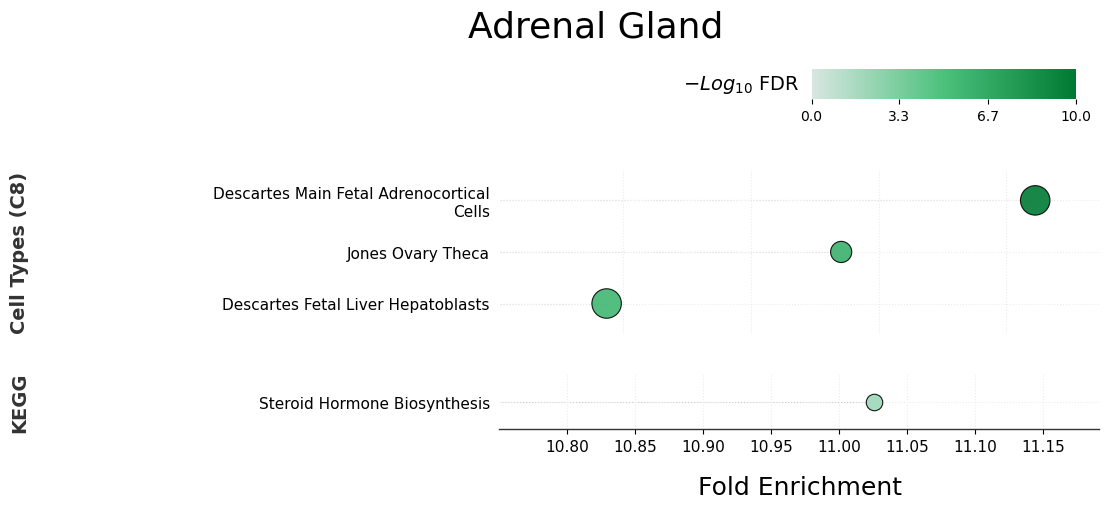

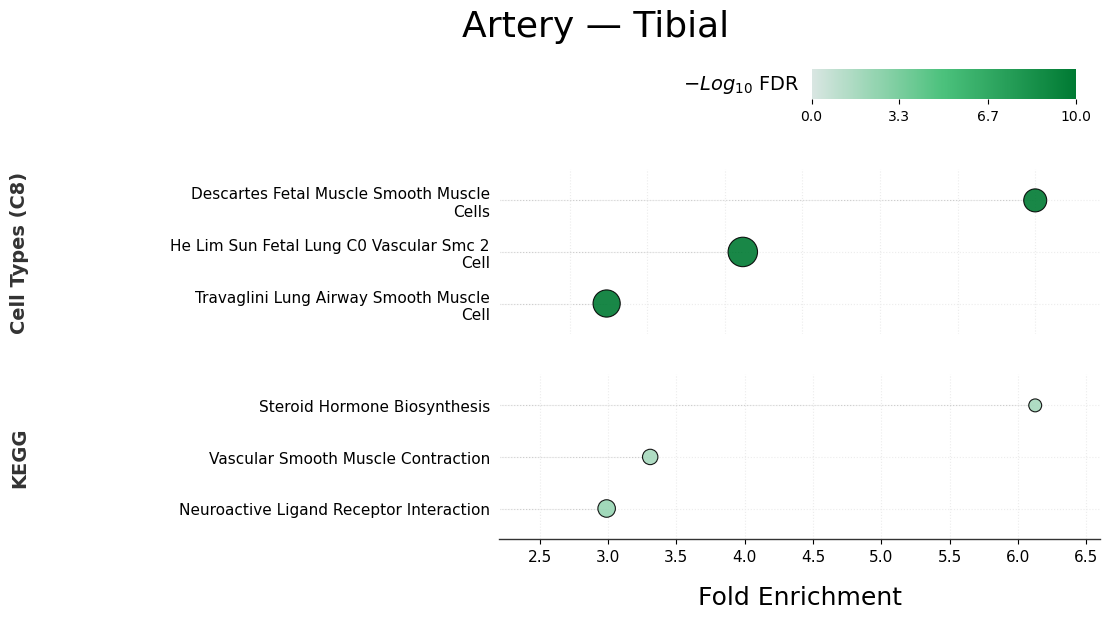

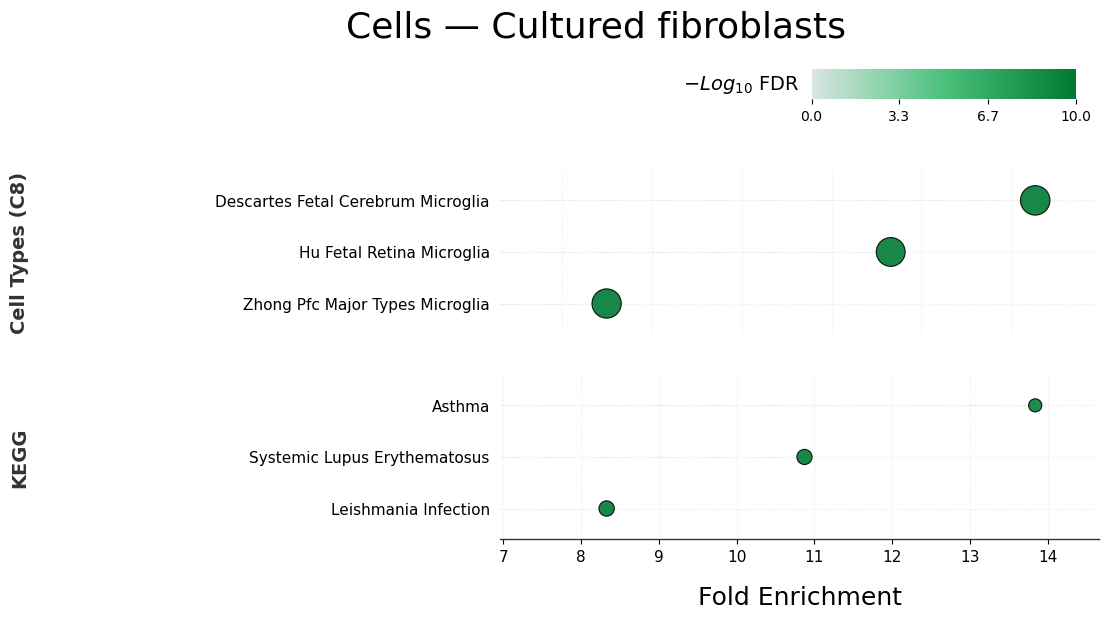

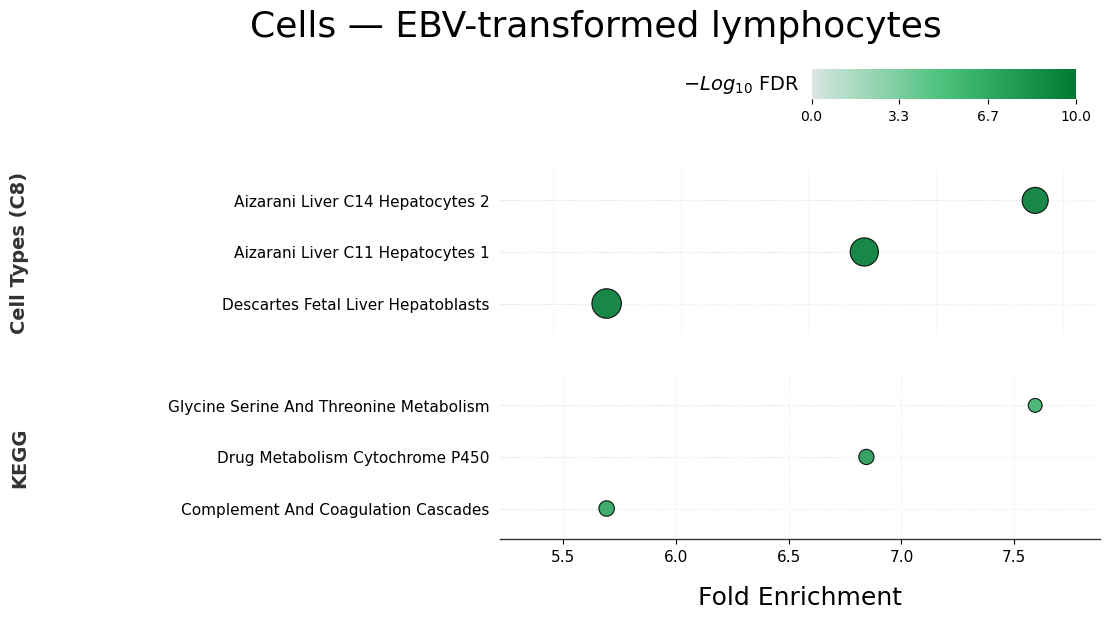

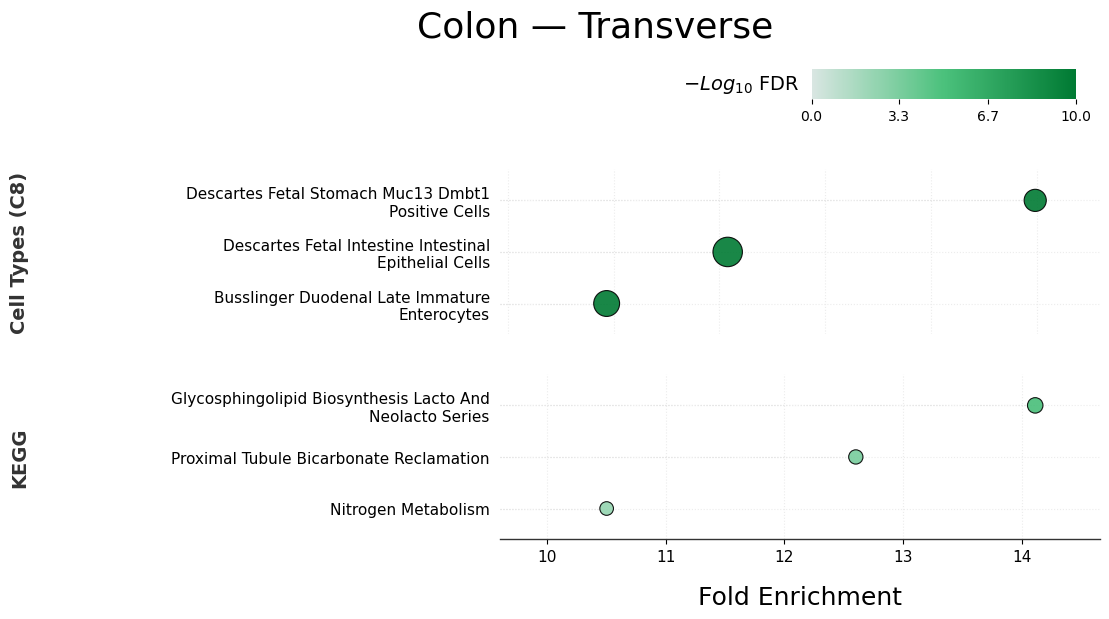

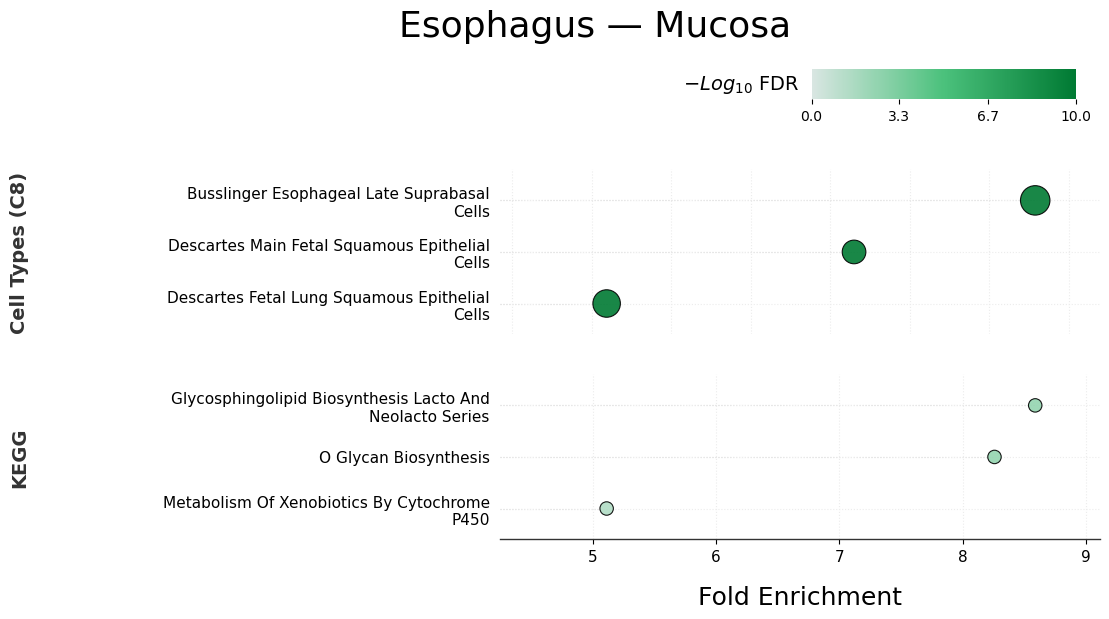

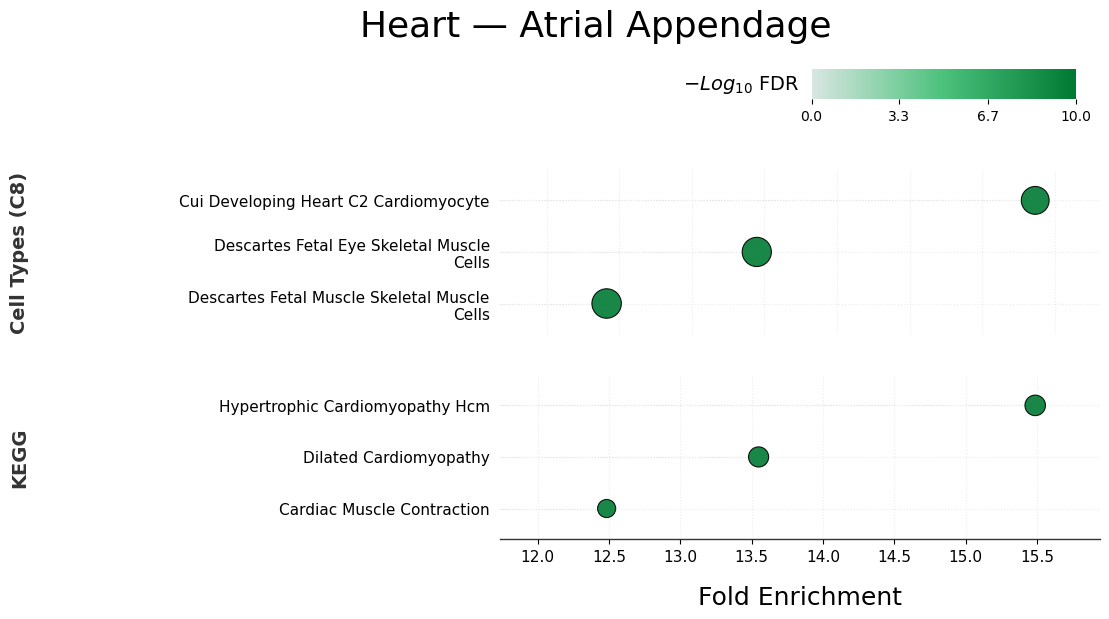

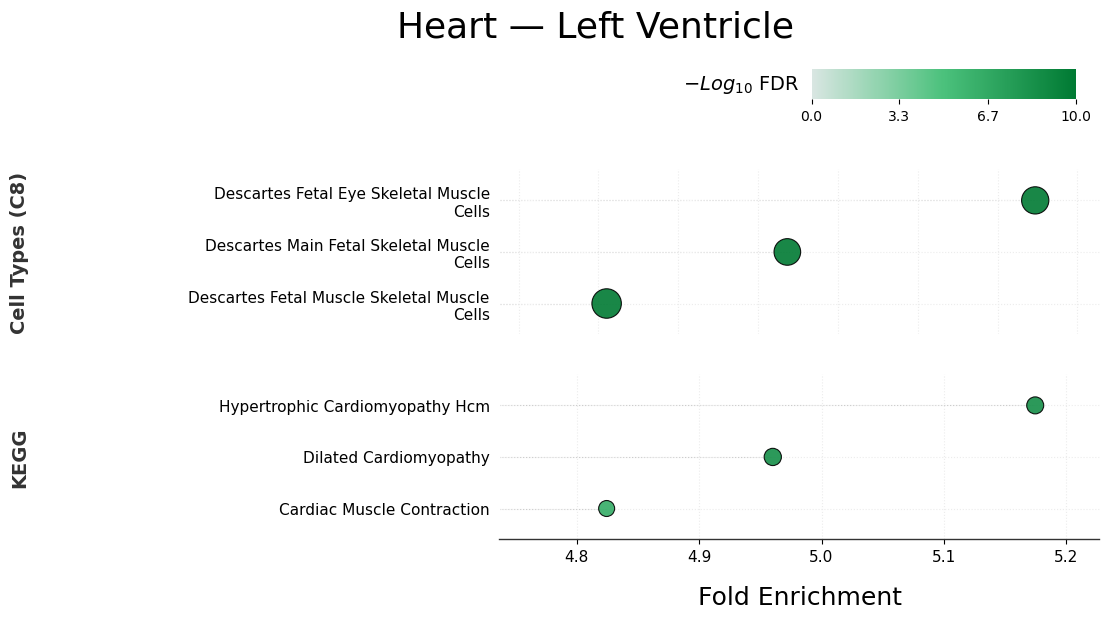

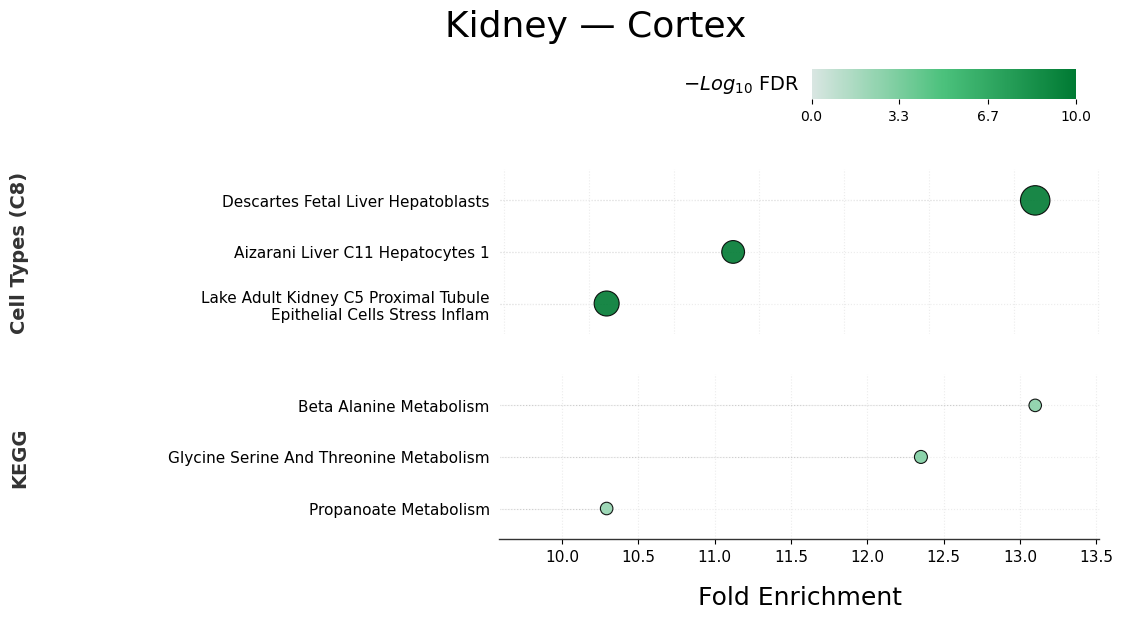

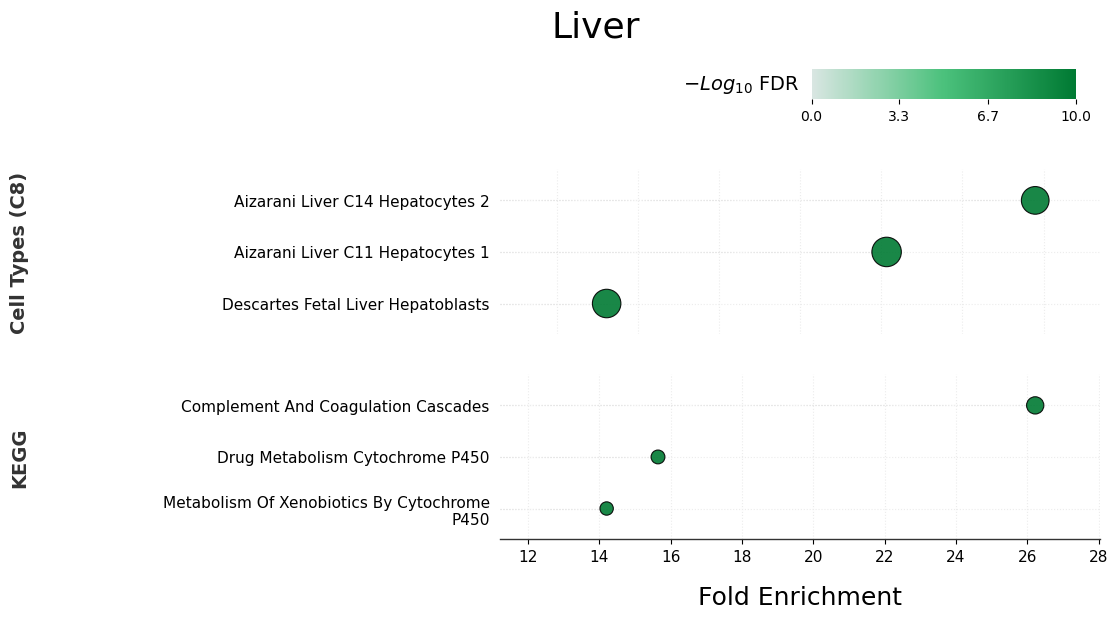

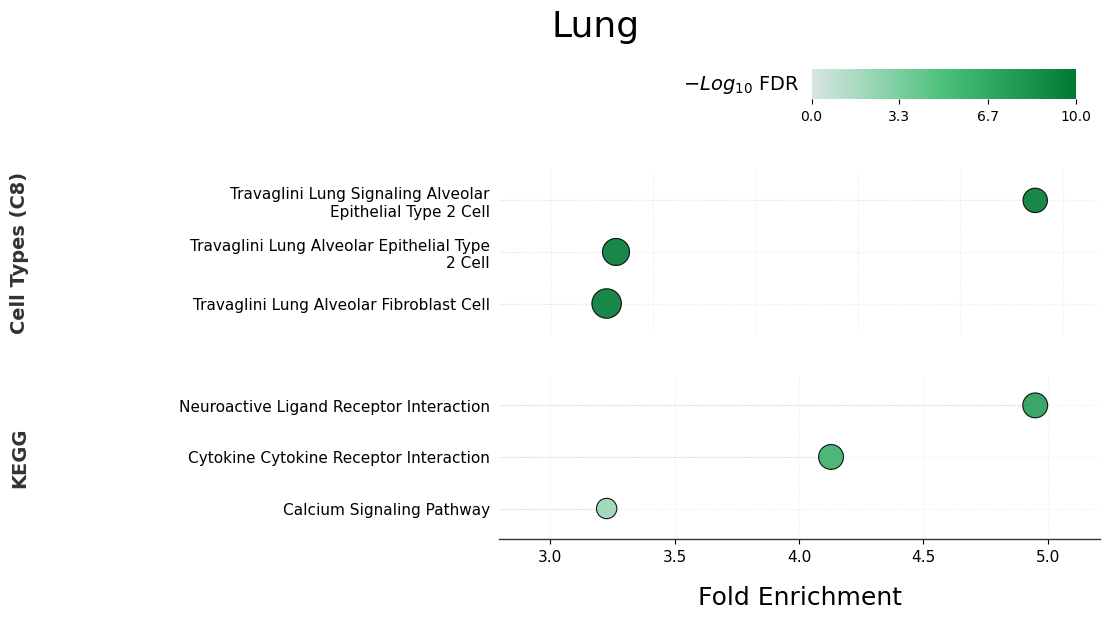

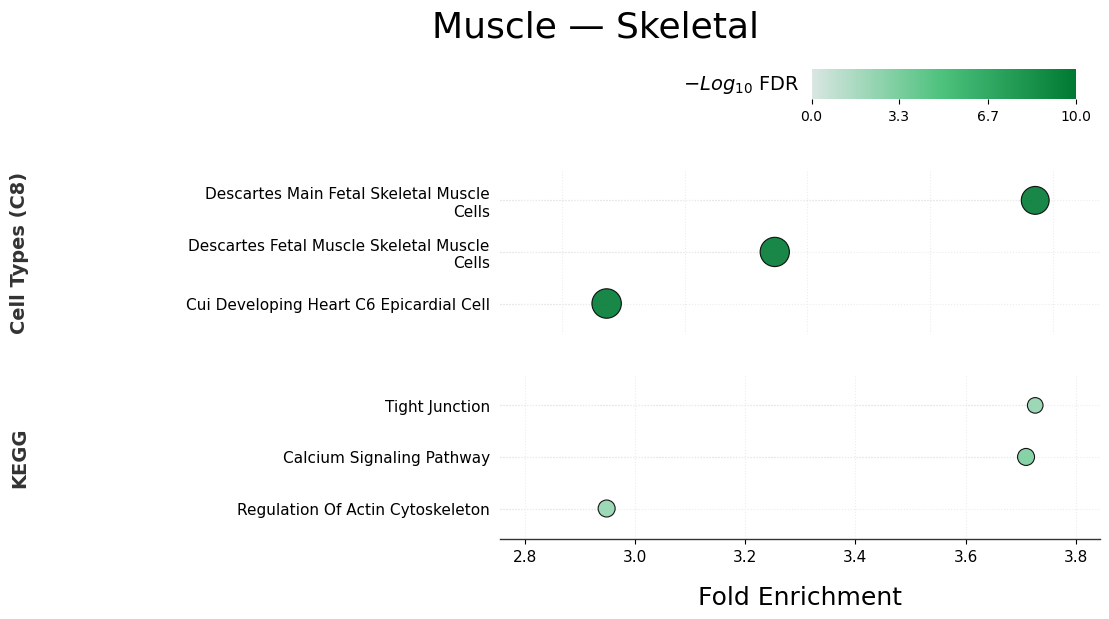

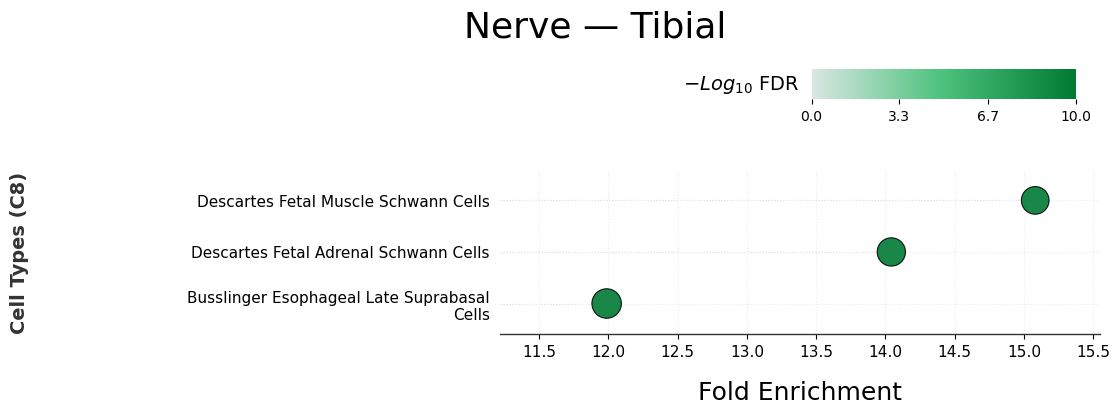

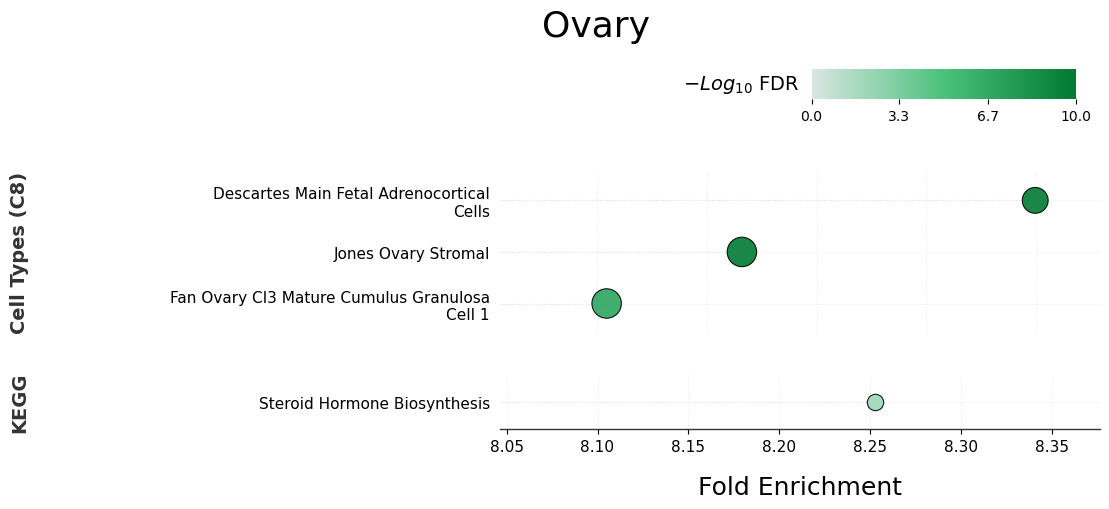

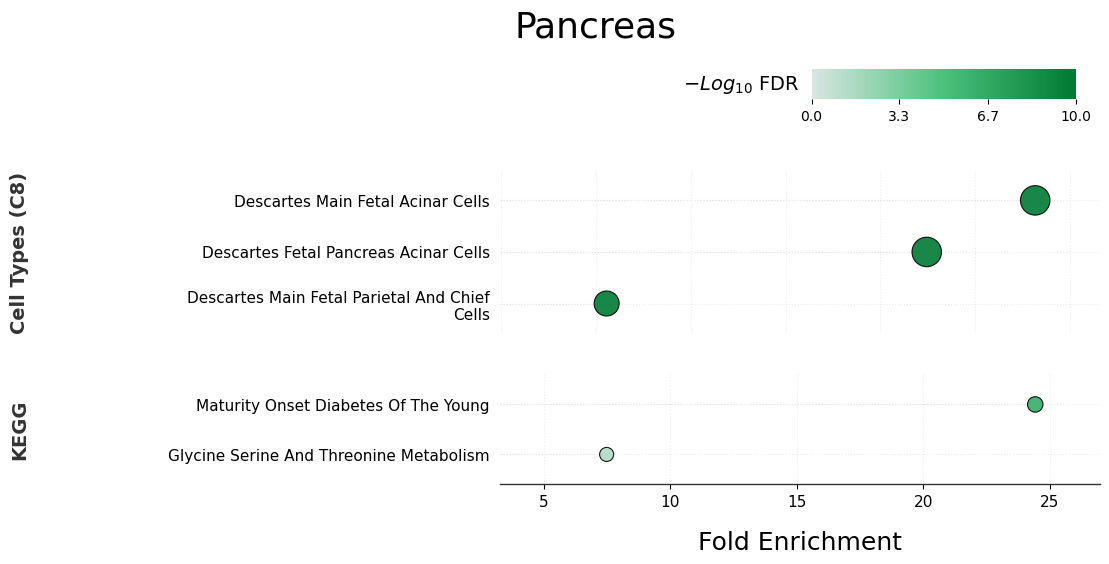

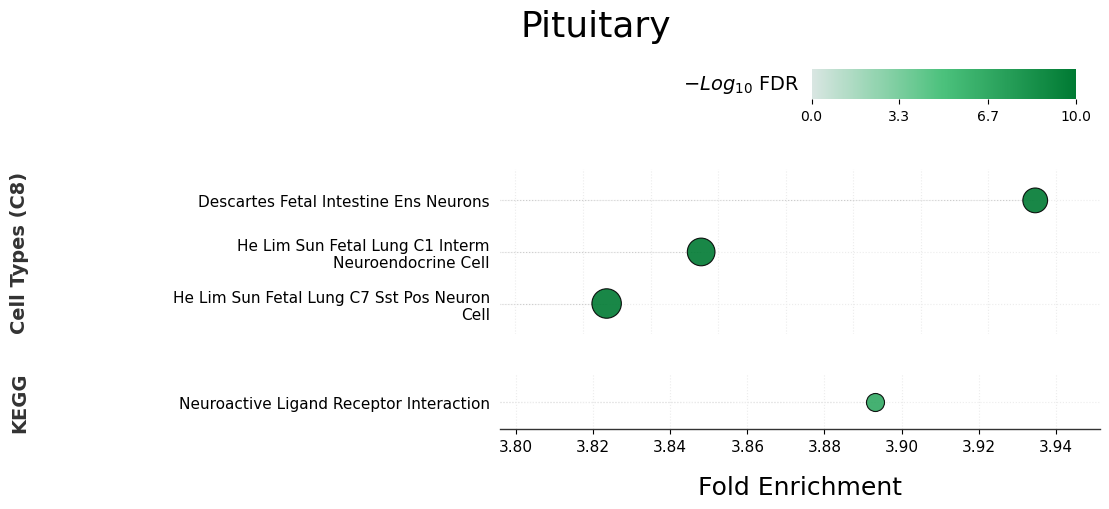

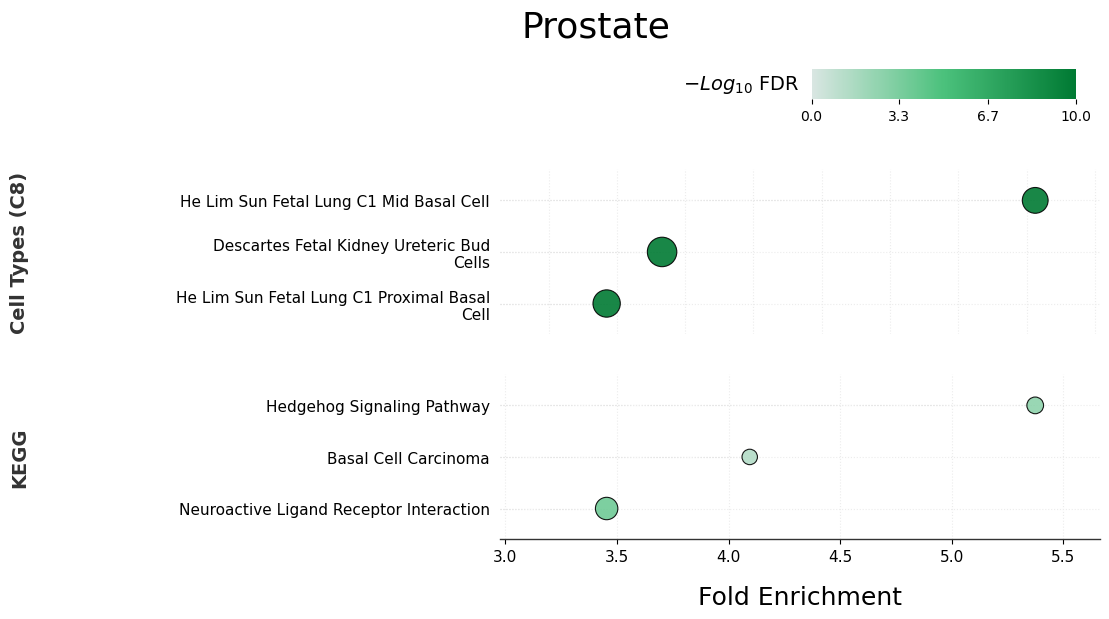

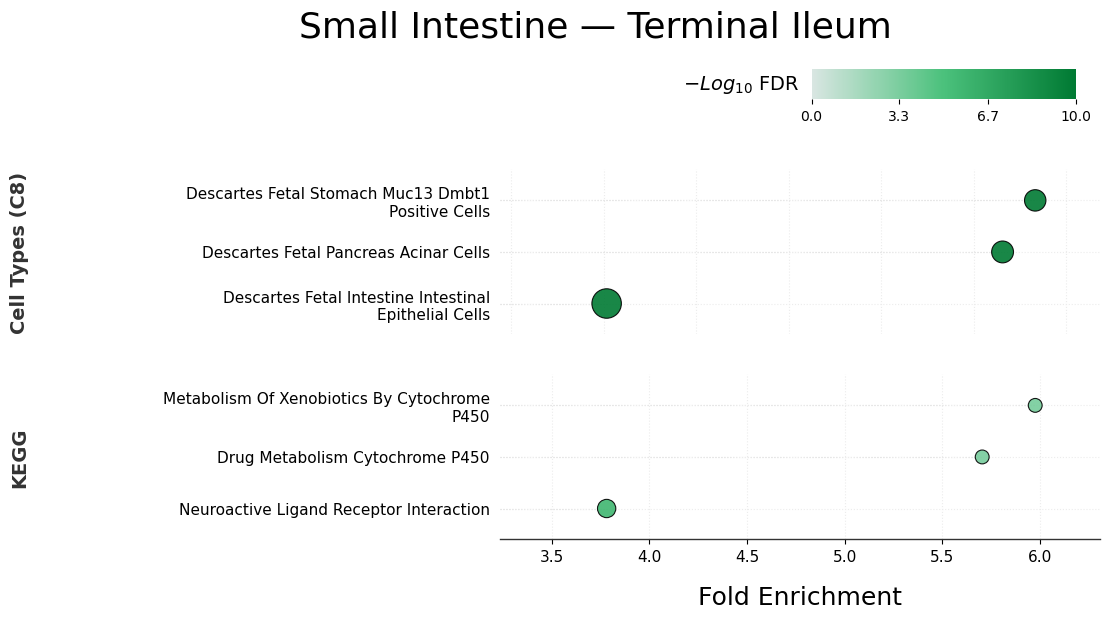

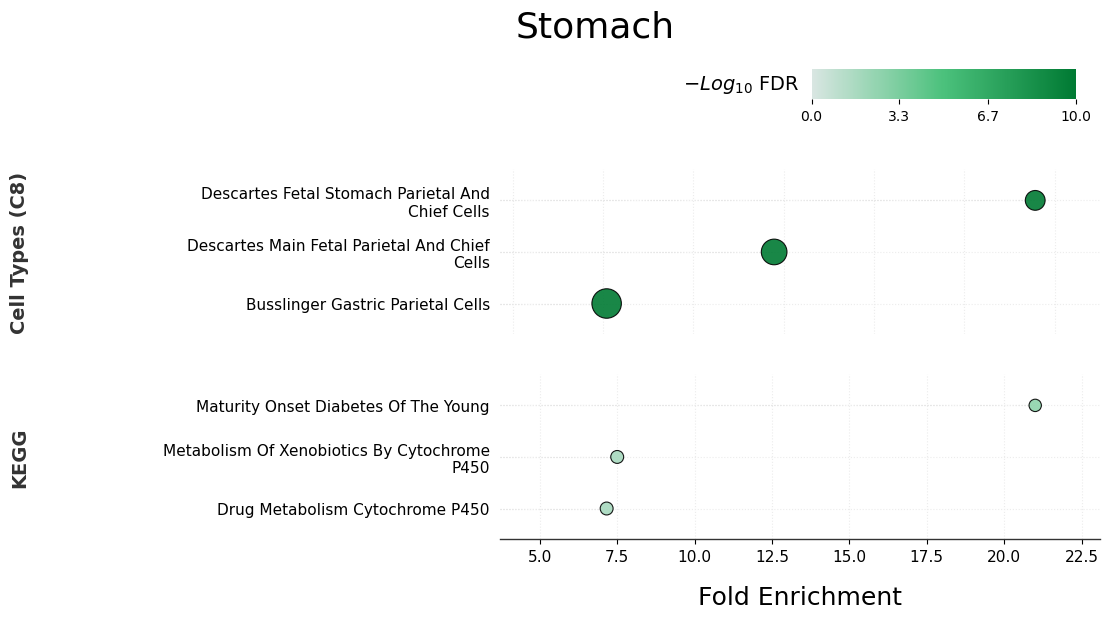

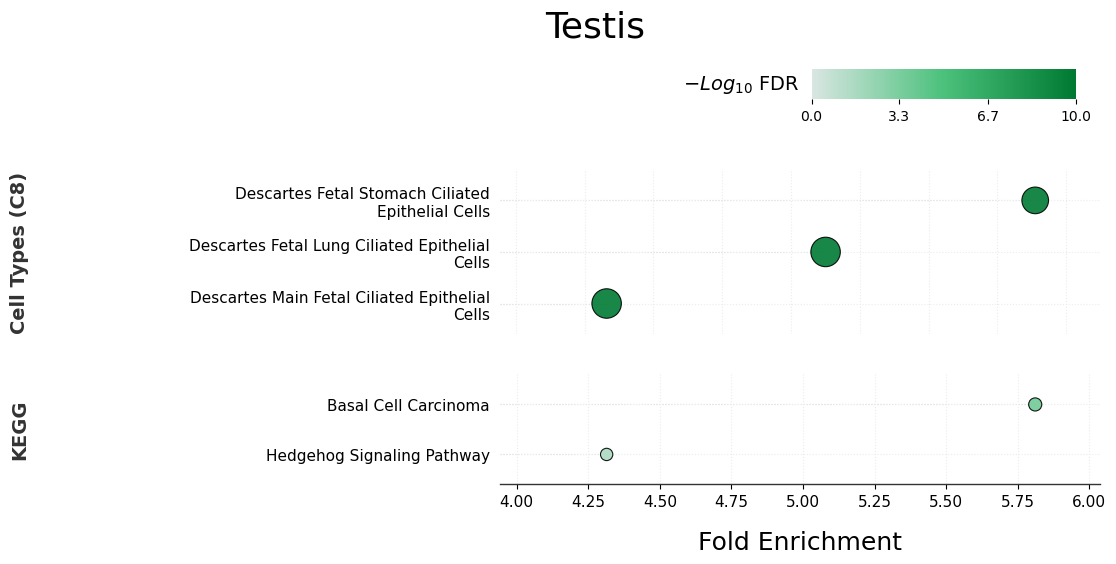

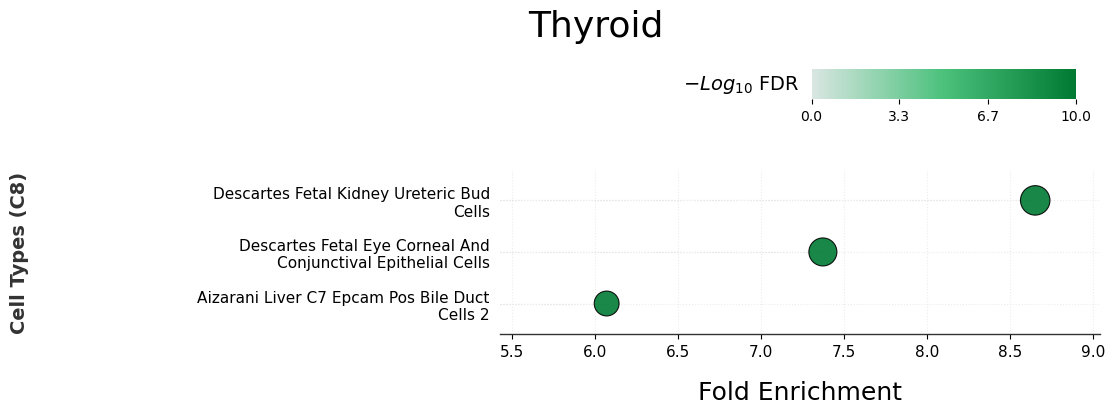

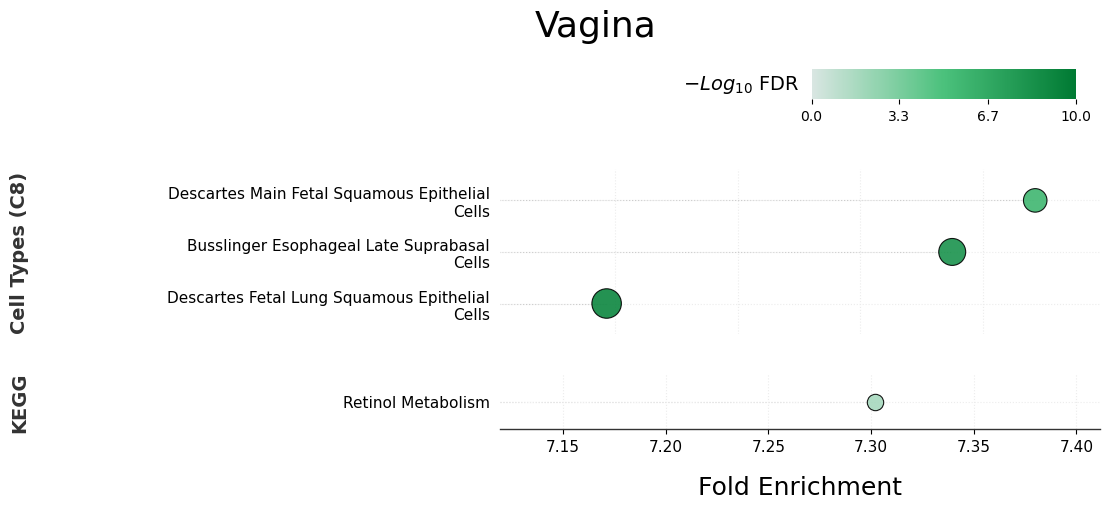

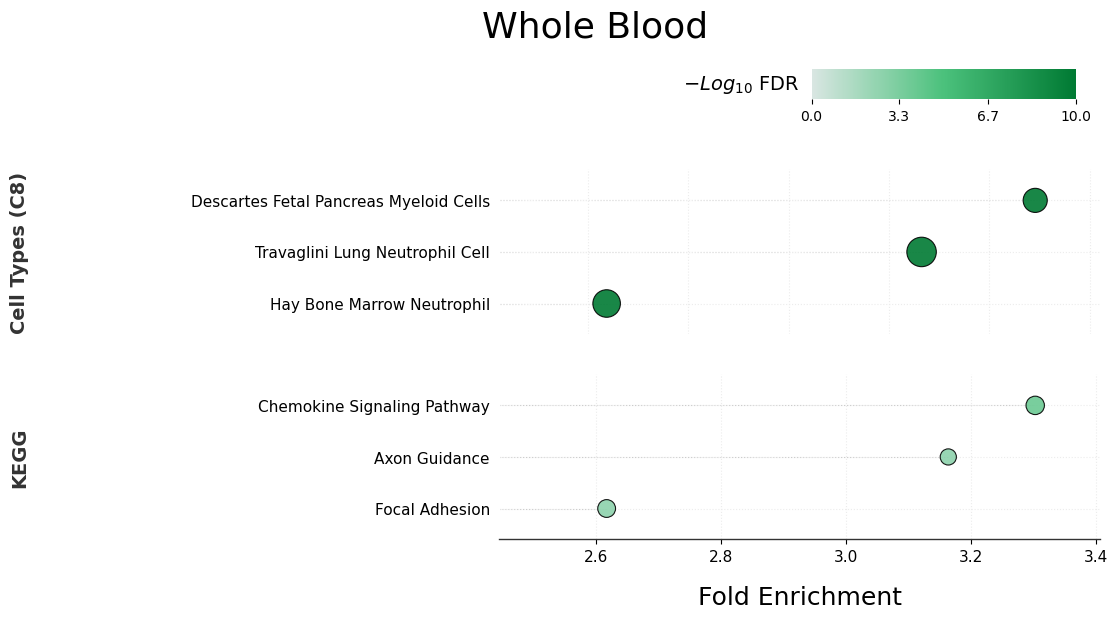

In [11]:
for tissue in valid_tissues:
    n_c8   = 0 if ora_c8[tissue]   is None else (ora_c8[tissue]['p.adjust']   < FDR_THRESH).sum()
    n_kegg = 0 if ora_kegg[tissue] is None else (ora_kegg[tissue]['p.adjust'] < FDR_THRESH).sum()
    if min(n_c8, 3) + min(n_kegg, 3) == 0:
        continue
    plot_ora_combined(ora_c8[tissue], ora_kegg[tissue], tissue, top_k=3)

## Per-LV ORA (genes not pooled)

Instead of pooling genes across all top LVs for a tissue, ORA is run **independently for each LV**.
Significant hits from all LVs are then merged per tissue, keeping the best (lowest FDR)
result per gene set along with the contributing LV.

In [12]:
ora_c8_perlv   = {t: {} for t in valid_tissues}
ora_kegg_perlv = {t: {} for t in valid_tissues}

for tissue in valid_tissues:
    for lv in top_per_tissue[tissue]:
        query = lv_top_genes[lv]
        ora_c8_perlv[tissue][lv]   = run_ora(query, c8_t2g,   all_genes)
        ora_kegg_perlv[tissue][lv] = run_ora(query, kegg_t2g, all_genes)

In [13]:
def combine_perlv(lv_ora_dict, fdr_thresh=FDR_THRESH):
    """Collect all significant hits across LVs; keep best FDR per gene set."""
    dfs = []
    for lv, df in lv_ora_dict.items():
        if df is None or df.empty:
            continue
        df_lv = df.copy()
        df_lv['LV'] = lv
        dfs.append(df_lv)
    if not dfs:
        return None
    combined = pd.concat(dfs, ignore_index=True)
    combined = combined[combined['p.adjust'] < fdr_thresh]
    if combined.empty:
        return None
    return (combined
            .sort_values('p.adjust')
            .drop_duplicates(subset='ID', keep='first')
            .reset_index(drop=True))


combined_c8_perlv   = {t: combine_perlv(ora_c8_perlv[t])   for t in valid_tissues}
combined_kegg_perlv = {t: combine_perlv(ora_kegg_perlv[t]) for t in valid_tissues}

# Summary
pd.DataFrame({
    'Tissue':    valid_tissues,
    'C8_sets':   [0 if combined_c8_perlv[t]   is None else len(combined_c8_perlv[t])   for t in valid_tissues],
    'KEGG_sets': [0 if combined_kegg_perlv[t] is None else len(combined_kegg_perlv[t]) for t in valid_tissues],
})

,Tissue,C8_sets,KEGG_sets
0,Adrenal Gland,37,3
1,Artery - Tibial,176,9
2,Cells - Cultured fibroblasts,252,34
3,Cells - EBV-transformed lymphocytes,262,34
4,Colon - Transverse,76,11
5,Esophagus - Mucosa,104,10
6,Heart - Atrial Appendage,43,8
7,Heart - Left Ventricle,185,22
8,Kidney - Cortex,85,25
9,Liver,66,31


In [14]:
def plot_perlv_combined(c8_df, kegg_df, tissue, top_k=3):
    collections  = [('Cell Types (C8)', c8_df), ('KEGG', kegg_df)]
    section_data = []
    for name, df in collections:
        df_p = parse_ora_df(df, fdr_thresh=None, wrap_width=45)  # already filtered
        if df_p is None:
            continue
        df_top = df_p.nsmallest(top_k, 'p.adjust').sort_values('fold_enrich', ascending=False).reset_index(drop=True)
        section_data.append((name, df_top))

    if not section_data:
        return

    n_sections = len(section_data)
    n_total    = sum(len(d) for _, d in section_data)
    header_h, footer_h, item_h, gap_h = 2.0, 0.8, 0.55, 0.4

    fig_h = header_h + footer_h + (item_h * n_total) + (gap_h * max(0, n_sections - 1))
    fig   = plt.figure(figsize=(12, fig_h), facecolor='white')

    fig.text(0.5, 1.0 - (0.4 / fig_h),
             tissue.replace(' - ', ' \u2014 '), ha='center', va='top', fontsize=26)

    all_fdr = [v for _, d in section_data for v in d['neg_log_fdr']]
    fdr_max = min(10.0, max(3.0, np.ceil(max(all_fdr))))
    norm    = Normalize(vmin=0, vmax=fdr_max)

    cax_bottom = 1.0 - (1.3 / fig_h)
    cax  = fig.add_axes([0.68, cax_bottom, 0.22, 0.3 / fig_h])
    sm   = plt.cm.ScalarMappable(cmap=GREEN_CMAP, norm=norm)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.outline.set_visible(False)
    cbar.set_ticks(np.linspace(0, fdr_max, 4).round(1))
    fig.text(0.67, cax_bottom + (0.15 / fig_h),
             r'$-Log_{10}$ FDR', fontsize=14, ha='right', va='center')

    n_per = [len(d) for _, d in section_data]
    section_bottoms = []
    y = footer_h
    for n in reversed(n_per):
        section_bottoms.insert(0, y)
        y += item_h * n + gap_h

    max_count = max(c for _, d in section_data for c in d['Count'])
    axes = []
    for s_idx, (s_name, df) in enumerate(section_data):
        n_items = len(df)
        ax_bot  = section_bottoms[s_idx] / fig_h
        ax_h    = (item_h * n_items) / fig_h

        ax = fig.add_axes([0.42, ax_bot, 0.50, ax_h])
        axes.append(ax)

        labels      = df['label'].tolist()
        fold_enrich = df['fold_enrich'].tolist()
        fdr_logs    = df['neg_log_fdr'].tolist()
        counts      = df['Count'].tolist()
        fe_range    = max(fold_enrich) - min(fold_enrich) or min(fold_enrich) * 0.1
        x_start     = min(fold_enrich) - fe_range * 0.25
        x_lims      = (x_start, max(fold_enrich) + fe_range * 0.15)
        sizes       = [50 + (c / max_count) * 400 for c in counts]

        for i, x in enumerate(fold_enrich):
            ax.plot([x_start, x], [i, i], color='#cccccc', lw=0.8, ls=':', zorder=1)
        ax.scatter(fold_enrich, range(n_items), s=sizes, c=fdr_logs,
                   cmap=GREEN_CMAP, norm=norm, edgecolor='black', linewidth=0.8,
                   zorder=3, alpha=0.9)

        setup_bubble_ax(ax, labels, x_lims)

        if s_idx < n_sections - 1:
            ax.tick_params(axis='x', labelbottom=False, length=0)
            ax.spines['bottom'].set_visible(False)

        fig.text(0.02, ax_bot + ax_h / 2, s_name,
                 rotation=90, va='center', ha='center',
                 fontsize=14, color='#333333', fontweight='bold')

    axes[-1].set_xlabel('Fold Enrichment', fontsize=18, labelpad=15)
    plt.show()

### Per-LV combined plots per tissue (C8 + KEGG)

Labels show gene-set name followed by the LV that produced the best FDR for that set.

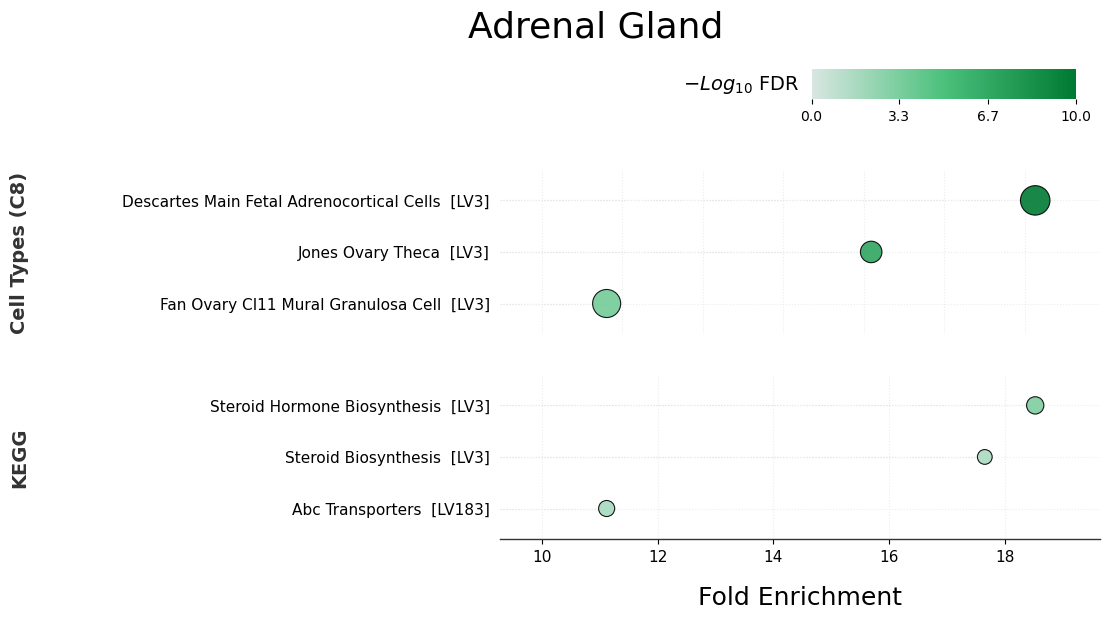

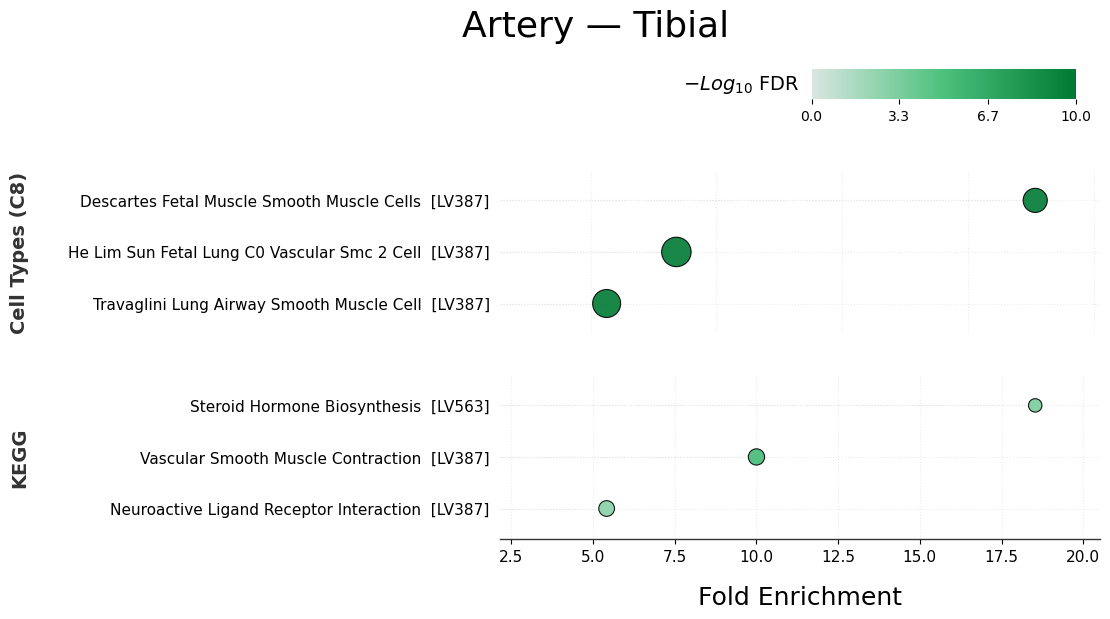

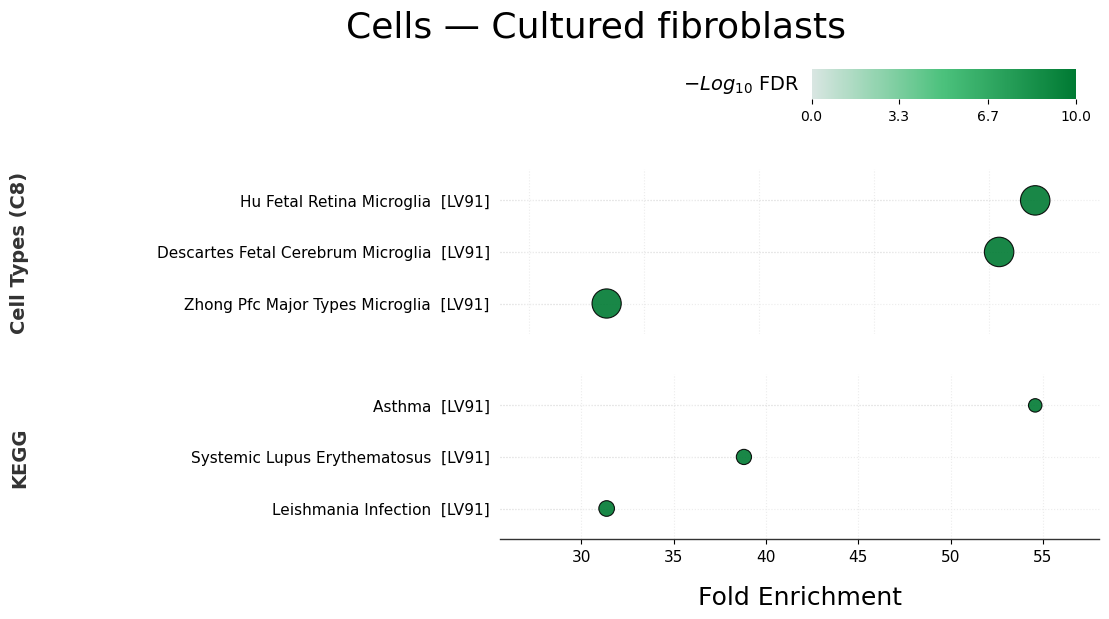

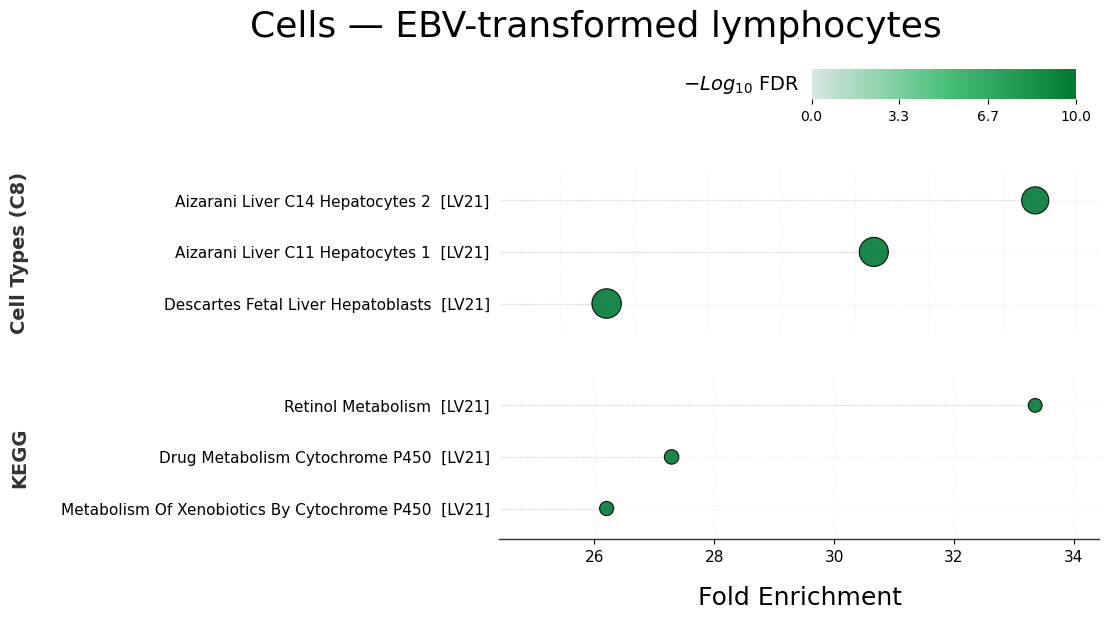

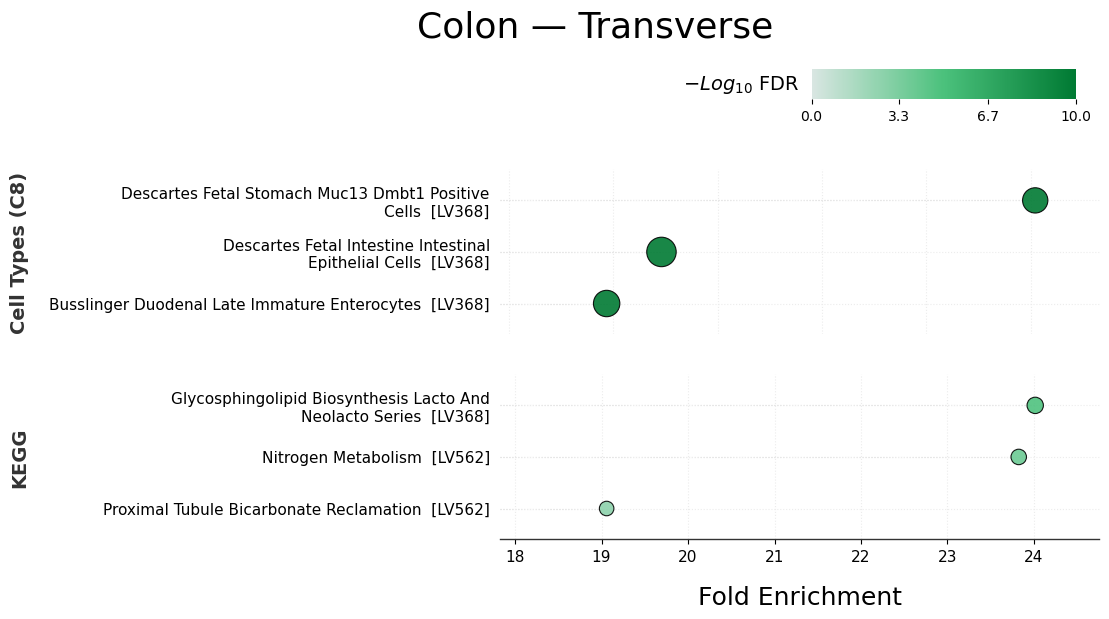

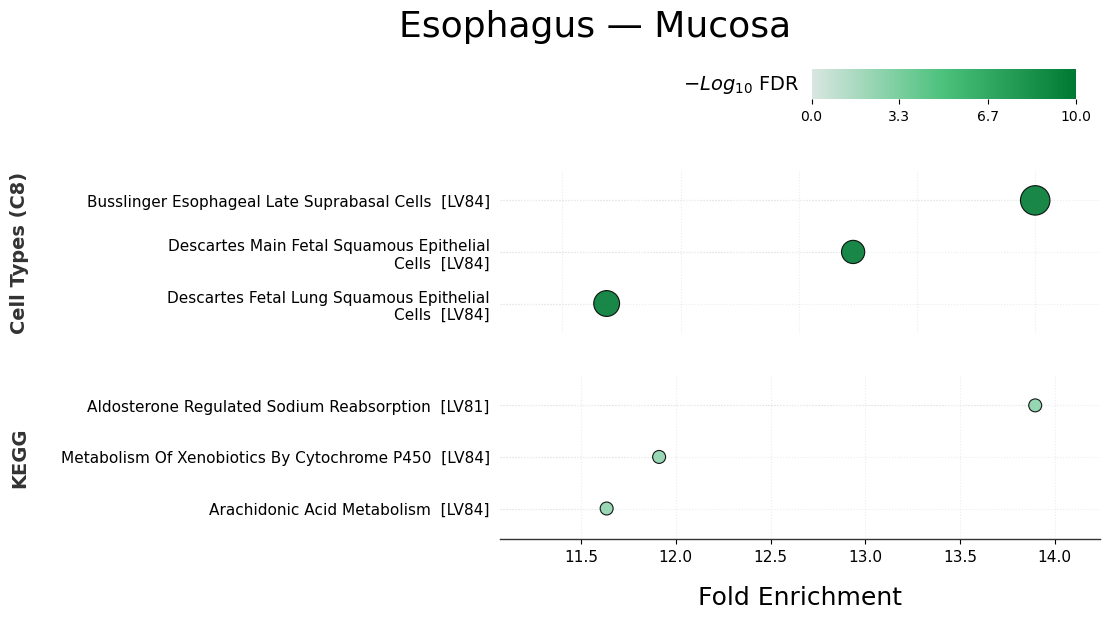

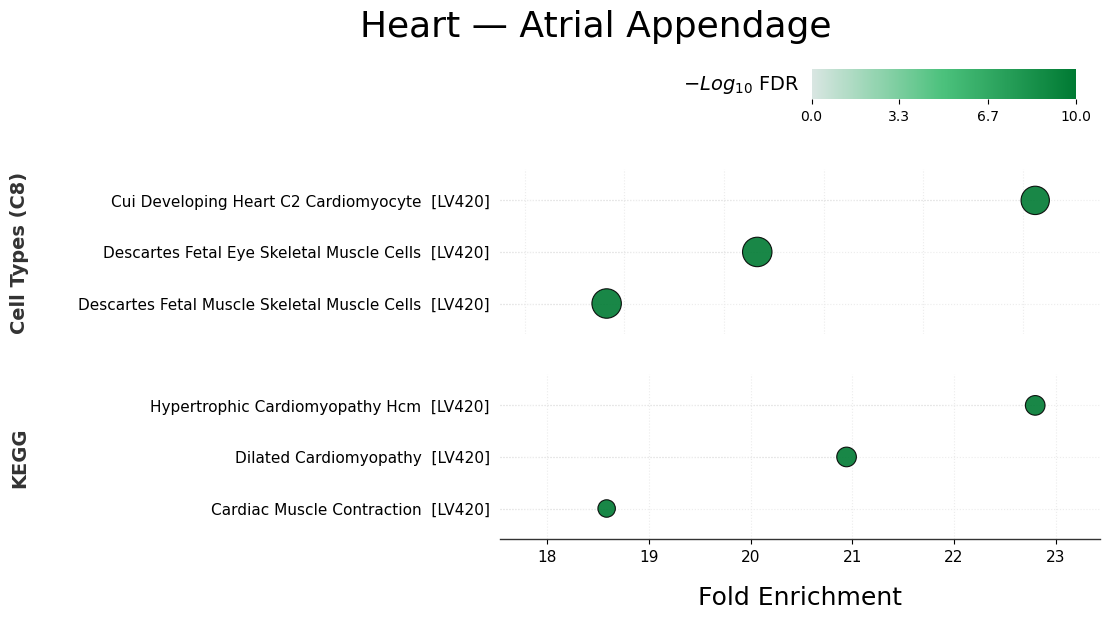

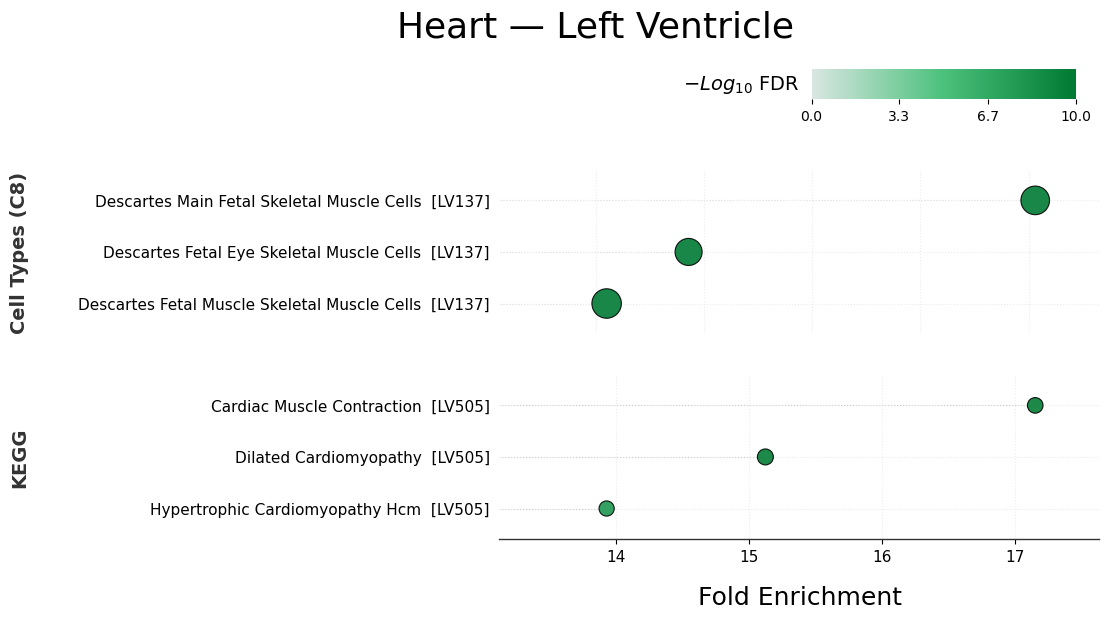

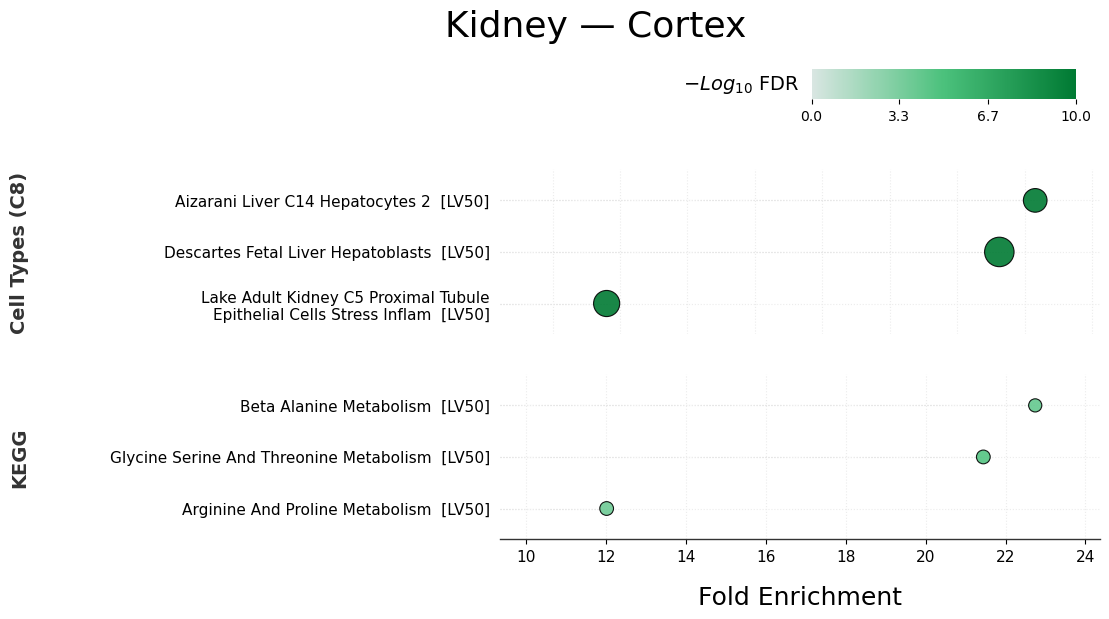

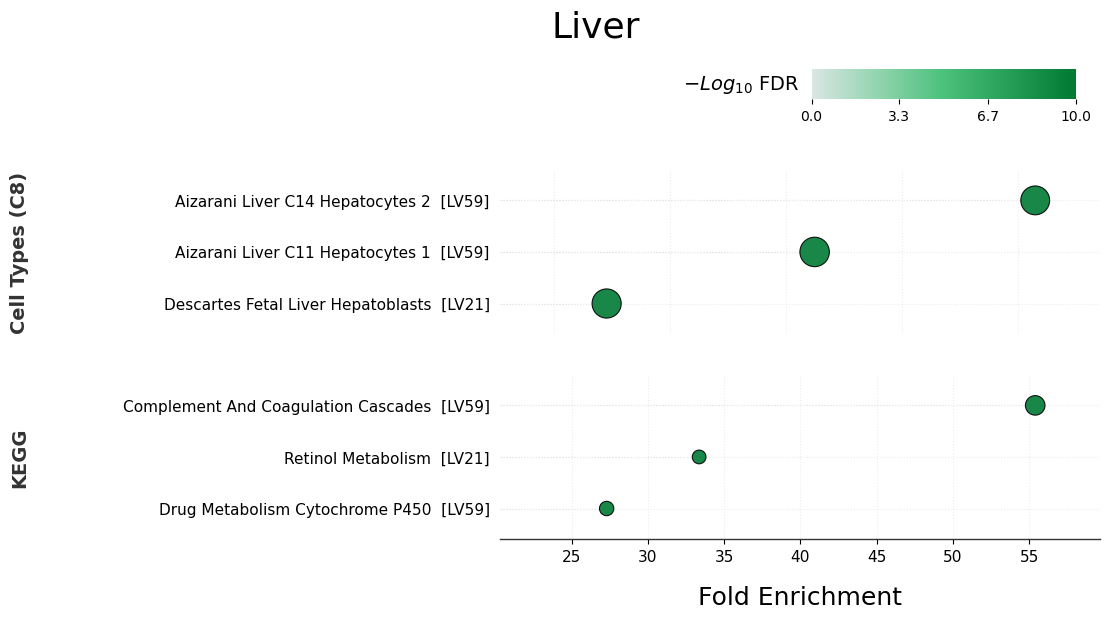

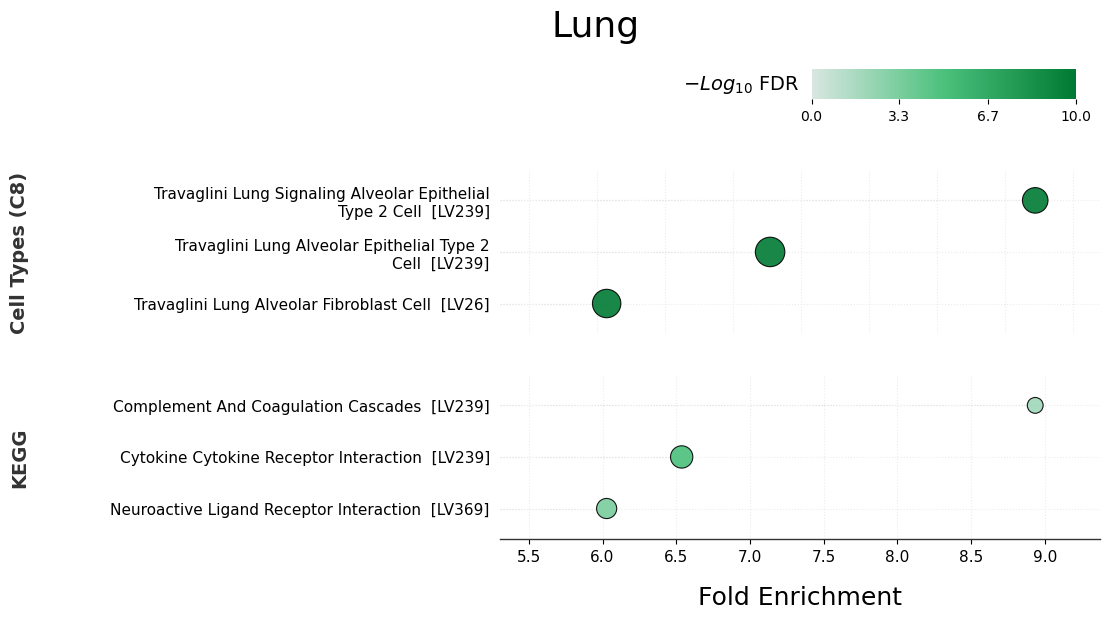

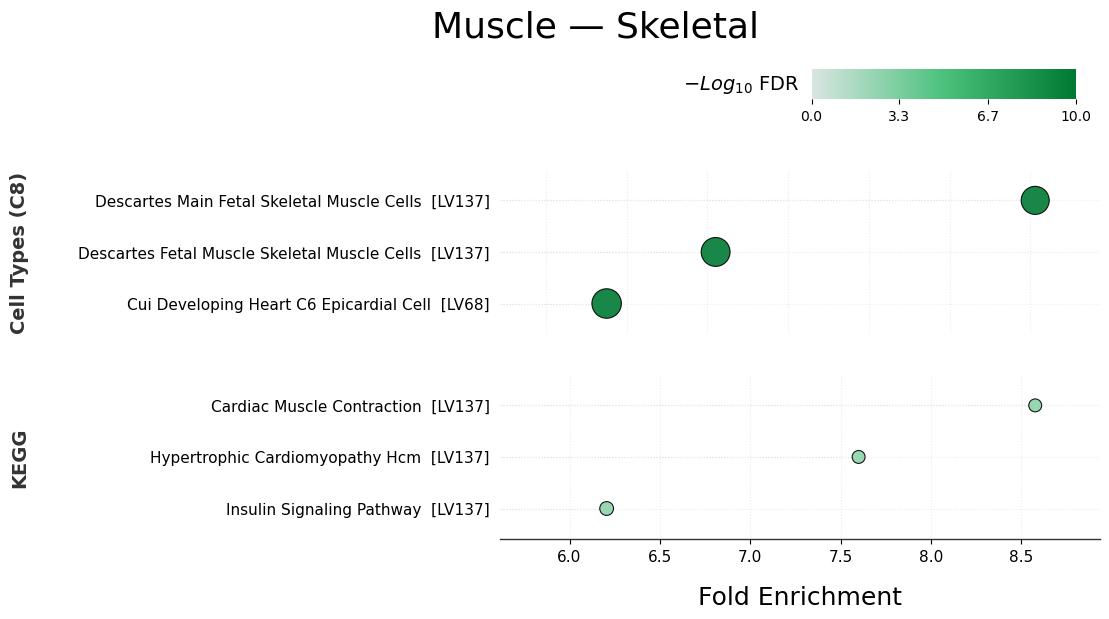

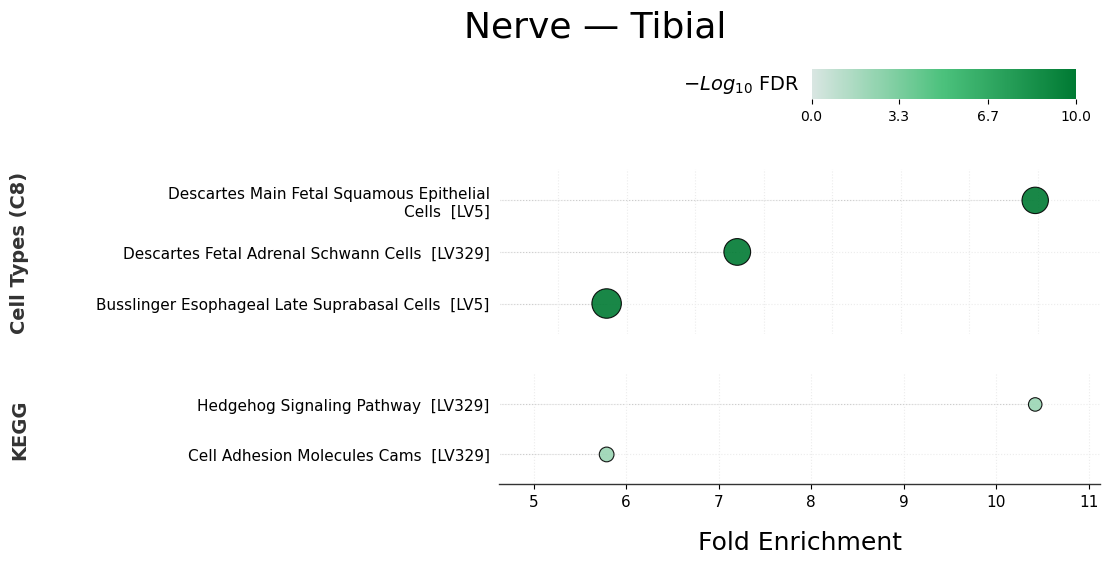

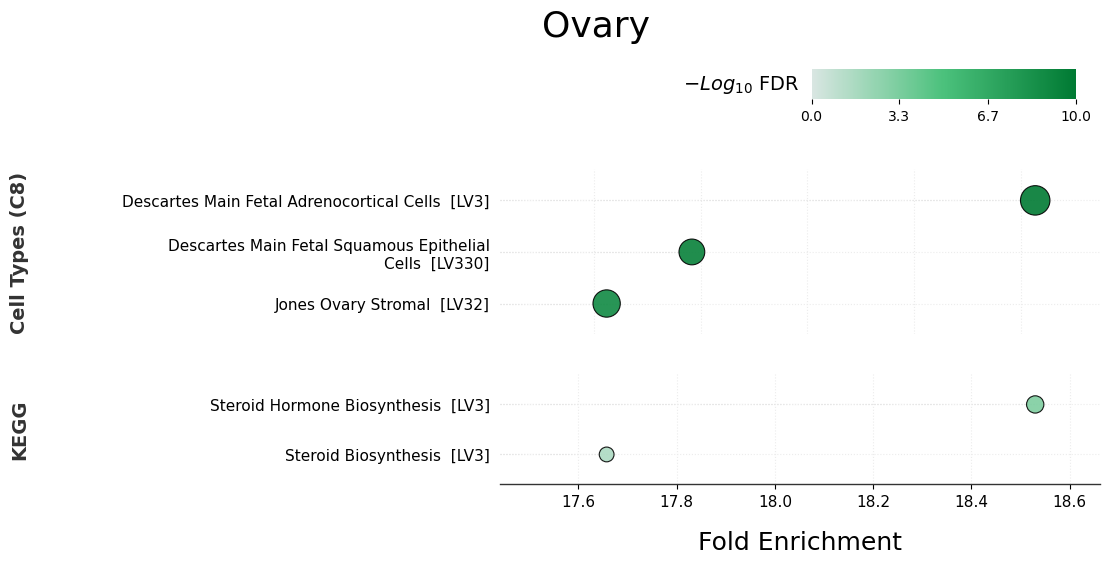

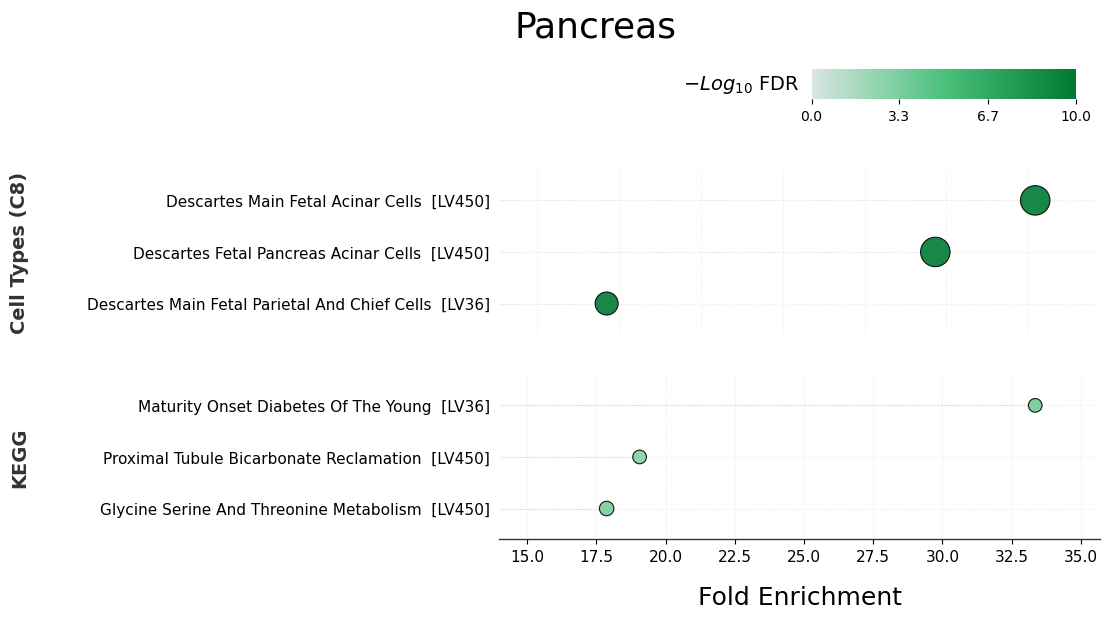

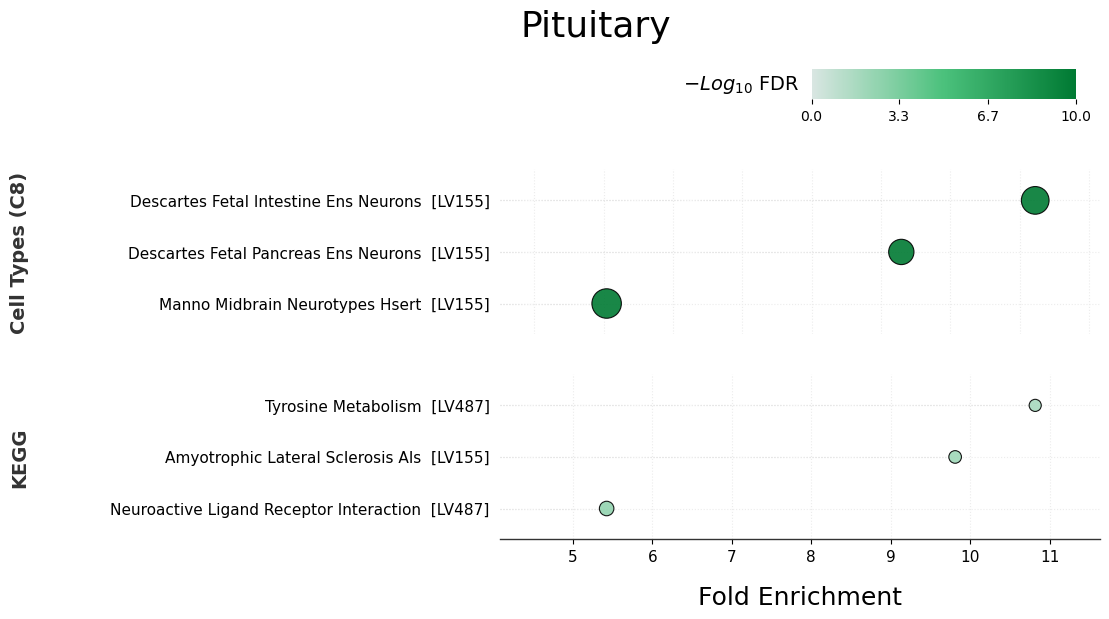

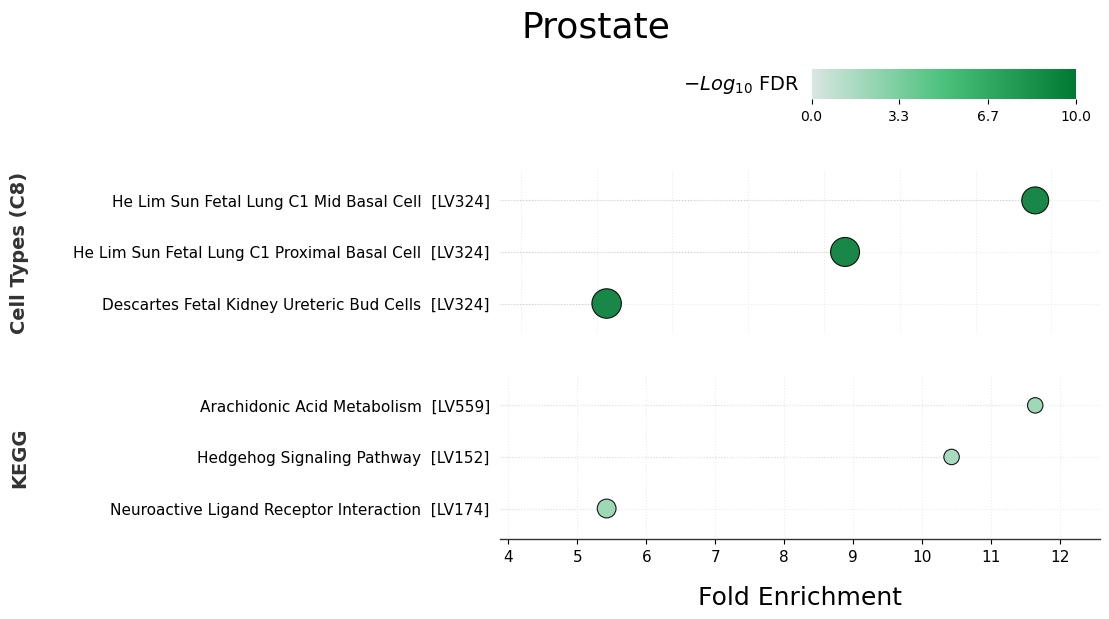

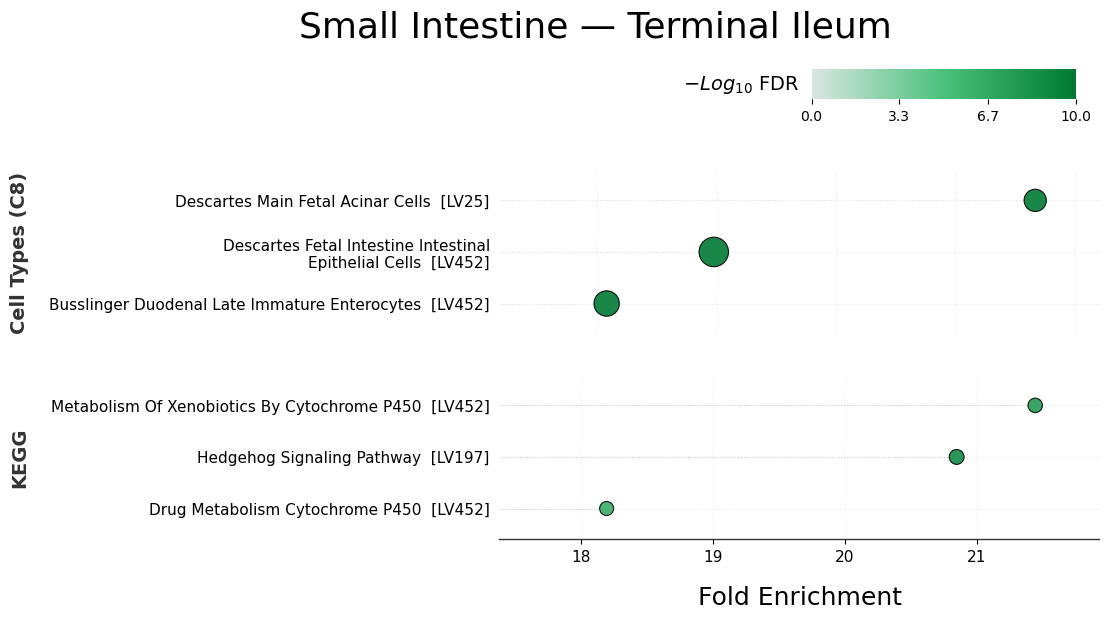

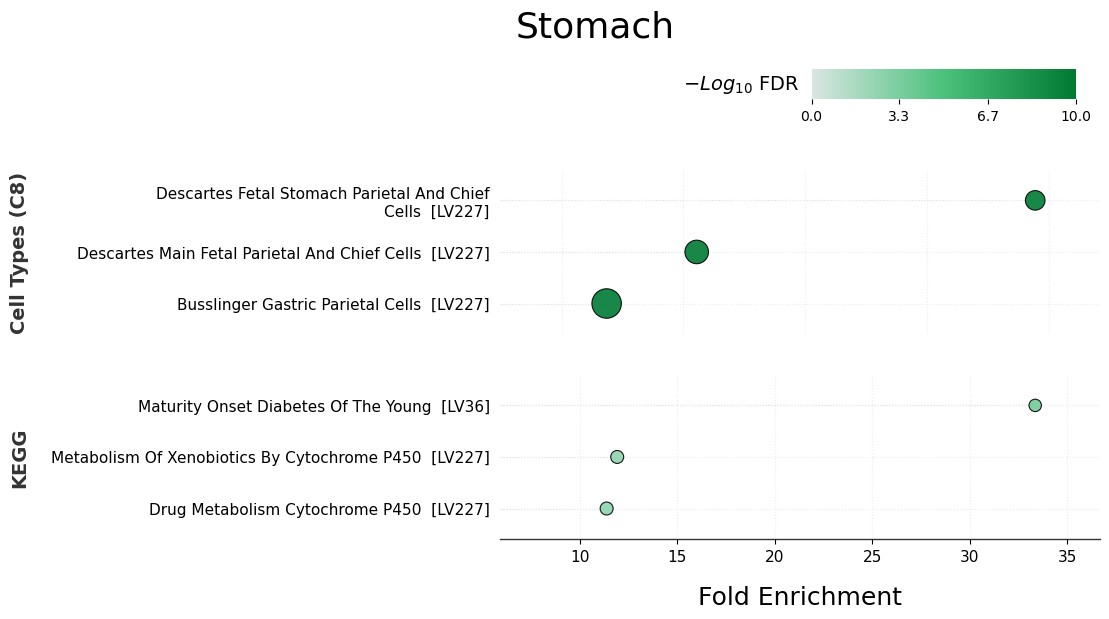

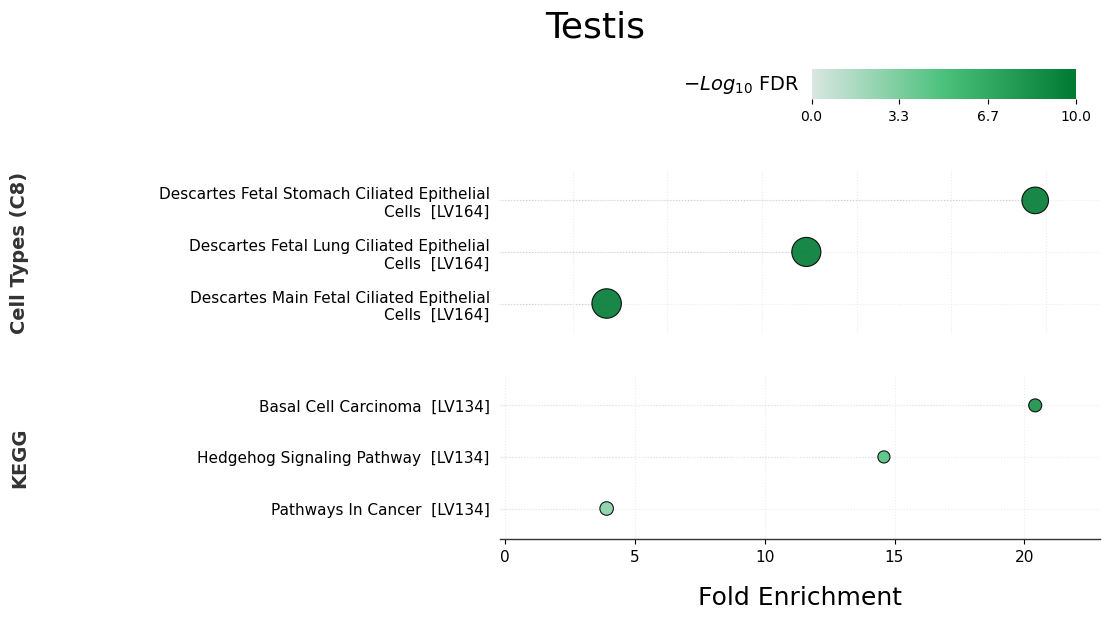

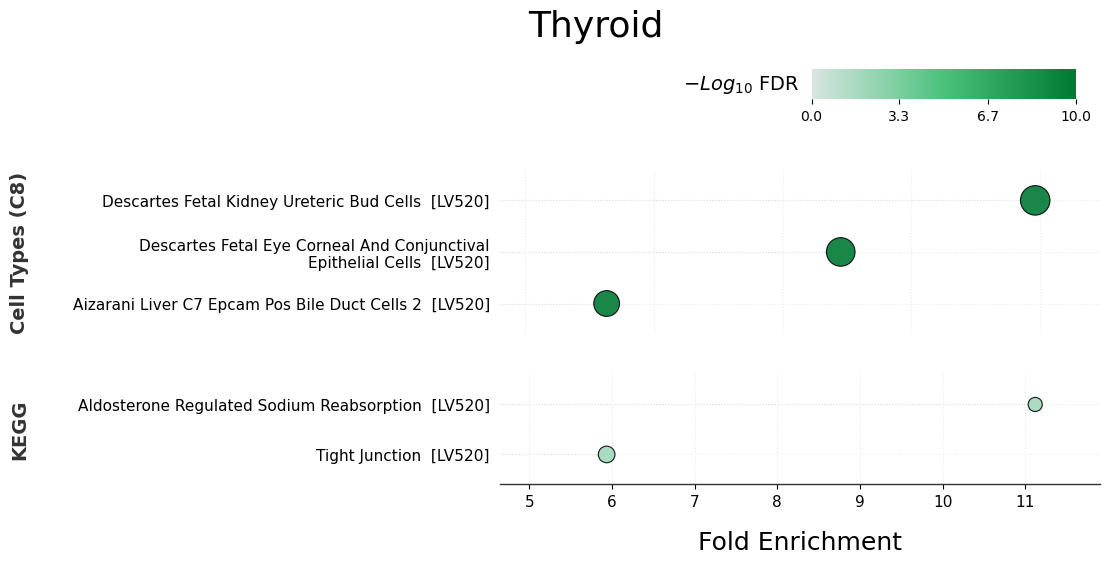

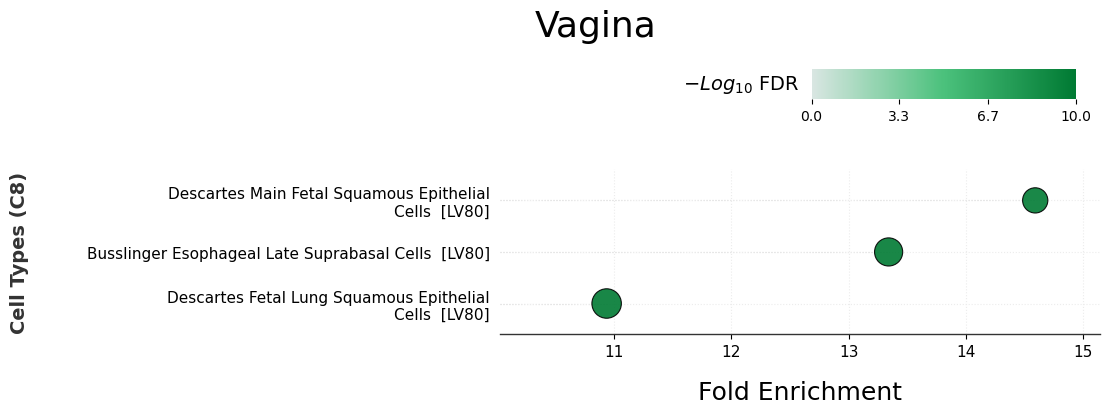

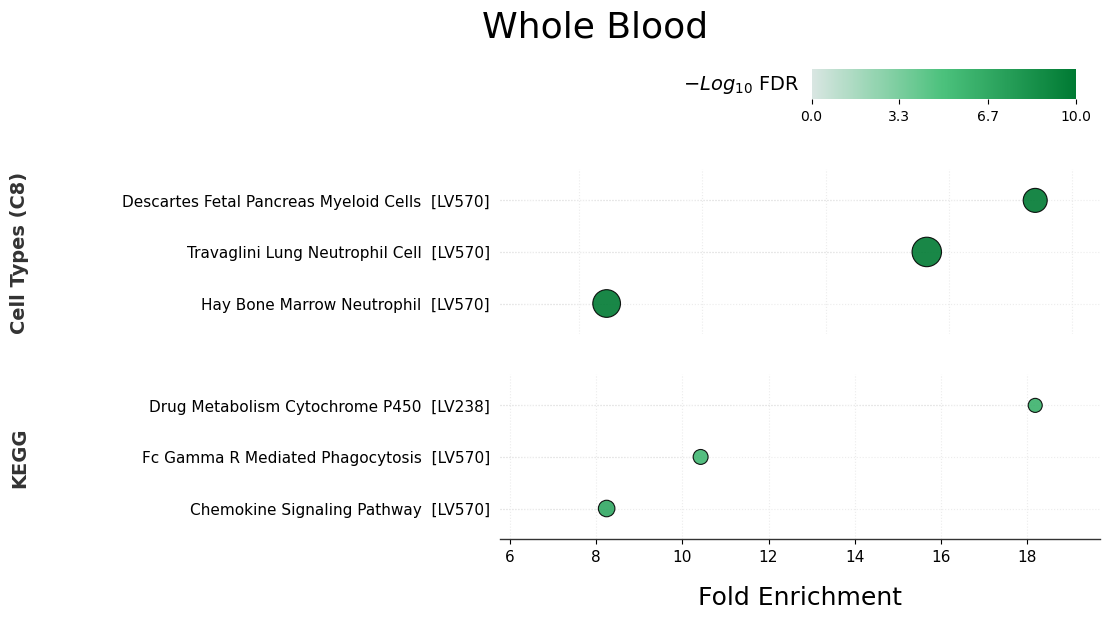

In [15]:
for tissue in valid_tissues:
    n_c8   = 0 if combined_c8_perlv[tissue]   is None else len(combined_c8_perlv[tissue])
    n_kegg = 0 if combined_kegg_perlv[tissue] is None else len(combined_kegg_perlv[tissue])
    if min(n_c8, 3) + min(n_kegg, 3) == 0:
        continue
    plot_perlv_combined(combined_c8_perlv[tissue], combined_kegg_perlv[tissue], tissue, top_k=3)

## Save panel data

Saves C8 and KEGG ORA results for Heart and Liver panel figure.

In [16]:
# ── Save tissue ORA data for fig2 panel ──────────────────────────────────────
from pathlib import Path as _Path

_panel_dir = _Path(str(here('output/99_panels/fig2')))
_panel_dir.mkdir(parents=True, exist_ok=True)

_PANEL_TISSUES = ['Heart - Atrial Appendage', 'Heart - Left Ventricle', 'Liver']

def _parse_ratio(r):
    _a, _b = r.split('/')
    return int(_a) / int(_b)

for _tissue in _PANEL_TISSUES:
    _fname  = _tissue.replace(' - ', '_').replace(' ', '_').lower()
    _parts  = []

    for _cname, _cdict in [('C8', combined_c8_perlv), ('KEGG', combined_kegg_perlv)]:
        _df = _cdict.get(_tissue)
        if _df is None or len(_df) == 0:
            continue
        _df = _df.copy()
        _df['fold_enrich'] = _df['GeneRatio'].apply(_parse_ratio) / _df['BgRatio'].apply(_parse_ratio)
        _df['neg_log_fdr'] = np.minimum(-np.log10(np.maximum(_df['p.adjust'], 1e-10)), 10)
        _df['collection']  = _cname
        _parts.append(_df)

    if _parts:
        _out = pd.concat(_parts, ignore_index=True)
        _out.to_csv(_panel_dir / f'tissue_ora_{_fname}.csv', index=False)
        print(f'  {_tissue}: {len(_out)} ORA rows')
    else:
        print(f'  {_tissue}: no ORA results')

print('Done.')


  Heart - Atrial Appendage: 51 ORA rows
  Heart - Left Ventricle: 207 ORA rows
  Liver: 97 ORA rows
Done.
